# Brain Tumor MRI Classification
**Swin-Tiny Pipeline | Dataset 1**

---
### Features
- 5-Fold Stratified Cross Validation
- Swin-Tiny (ImageNet-1K pretrained, last 2 transformer stages fine-tuned)
- Class imbalance handling with per-fold weights
- Best epoch selection by Macro F1
- Mixed precision training (AMP)
- Early stopping + CosineAnnealingWarmRestarts
- Bootstrap 95% CI for all metrics
- Kappa + MCC for imbalanced classification
- Clinical metrics (Sensitivity, Specificity, PPV, NPV)
- Grad-CAM++ + Attention Rollout + LIME visualizations
- Per-class ROC curves (publication figure)
- McNemar test for cross-model statistical comparison


## 1. Install dependencies

In [1]:
!pip -q install albumentations==1.4.6 lime scikit-image statsmodels


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 6.7 MB/s eta 0:00:00


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 3. Imports

In [3]:
import os, json, random, warnings, time, platform
from collections import Counter
from datetime import datetime

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef)
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.cuda.amp import GradScaler, autocast

from lime import lime_image
from skimage.segmentation import mark_boundaries

warnings.filterwarnings("ignore")
print("✅ All imports successful")


✅ All imports successful


## 4. Config — change paths here

In [4]:
# === Change these only ===
MODEL_NAME      = "swin_tiny"
EXPERIMENT      = "SwinTiny"
DATASET_NAME    = "Dataset1"

TRAIN_ROOT = "/content/drive/MyDrive/Brain_MRI_Images/Training"
TEST_ROOT  = "/content/drive/MyDrive/Brain_MRI_Images/Testing"

# === Training hyperparameters ===
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 60
KFOLDS          = 5
PATIENCE        = 10            # Transformers converge slower
FINE_TUNE_AT    = 2             # last N Swin transformer stages
LEARNING_RATE   = 5e-5          # Transformers need smaller LR
WEIGHT_DECAY    = 5e-3          # stronger regularisation for Swin
DROPOUT_RATES   = [0.3, 0.2]   # Swin has built-in stochastic-depth dropout
LR_FACTOR       = 0.5
LR_PATIENCE     = 3
LR_MIN          = 1e-7
SEED            = 42

# === Options ===
USE_AMP          = True
SAVE_MODELS      = True
BEST_METRIC      = "f1"
LIME_NUM_SAMPLES = 500
BOOTSTRAP_N      = 1000
NUM_WORKERS      = min(2, os.cpu_count() or 0)

# === Output directories ===
OUTPUT_DIR    = f"results_{EXPERIMENT}_{DATASET_NAME}"
CKPT_DIR      = f"checkpoints_{EXPERIMENT}_{DATASET_NAME}"
ARTIFACTS_DIR = f"artifacts_{EXPERIMENT}_{DATASET_NAME}"
for d in [OUTPUT_DIR, CKPT_DIR, ARTIFACTS_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Device        : {DEVICE}")
print(f"Experiment    : {EXPERIMENT} on {DATASET_NAME}")
print(f"Run ID        : {RUN_ID}")
print(f"Selection by  : {BEST_METRIC.upper()}")
print(f"Output dir    : {OUTPUT_DIR}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")


Device        : cuda
Experiment    : SwinTiny on Dataset1
Run ID        : 20260502_071608
Selection by  : F1
Output dir    : results_SwinTiny_Dataset1
Seed set to 42


## 5. Dataset class

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels     = labels
        self.transform  = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.file_paths[idx]).convert("RGB"))
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

print(" Dataset class ready")


 Dataset class ready


## 6. Augmentation pipelines

In [6]:
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

# Backward compatible CoarseDropout — works on old & new Albumentations
try:
    coarse_dropout = A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(8, 16),
        hole_width_range=(8, 16),
        p=0.3,
    )
except TypeError:
    coarse_dropout = A.CoarseDropout(
        max_holes=4, max_height=16, max_width=16, p=0.3,
    )

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomScale(scale_limit=0.1, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.4),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.15) , # MRI: reduced to avoid anatomical distortion,
    coarse_dropout,
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

AUG_LIST = ["HorizontalFlip", "Rotate±10", "RandomScale±10%",
            "BrightnessContrast±10%", "CLAHE", "GridDistortion", "CoarseDropout"]
print(f" Augmentations ready: {AUG_LIST}")


 Augmentations ready: ['HorizontalFlip', 'Rotate±10', 'RandomScale±10%', 'BrightnessContrast±10%', 'CLAHE', 'GridDistortion', 'CoarseDropout']


## 7. Load data paths

In [7]:
def collect_paths(root):
    if not os.path.exists(root):
        raise FileNotFoundError(f"Path not found: {root}")
    classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
    if not classes:
        raise ValueError(f"No class folders found in {root}")
    paths, labels = [], []
    for lbl, cls in enumerate(classes):
        cls_dir = os.path.join(root, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(lbl)
    return np.array(paths), np.array(labels), classes

train_paths, train_labels, class_names = collect_paths(TRAIN_ROOT)
num_classes = len(class_names)

print(f"Classes      : {class_names}")
print(f"Train images : {len(train_paths)}")

dist = Counter(train_labels.tolist())
for i, cls in enumerate(class_names):
    print(f"  {cls:15s}: {dist[i]:4d} images")

if os.path.exists(TEST_ROOT):
    test_paths, test_labels, test_classes = collect_paths(TEST_ROOT)
    assert test_classes == class_names, (
        f"Class mismatch!\nTrain: {class_names}\nTest:  {test_classes}")
    print(f"\nTest images  : {len(test_paths)}")
else:
    test_paths, test_labels = None, None
    print("[WARN] TEST_ROOT not found — test evaluation will be skipped.")


Classes      : ['glioma', 'meningioma', 'notumor', 'pituitary']
Train images : 5712
  glioma         : 1321 images
  meningioma     : 1339 images
  notumor        : 1595 images
  pituitary      : 1457 images

Test images  : 1311


## 8. Class weights & imbalance analysis

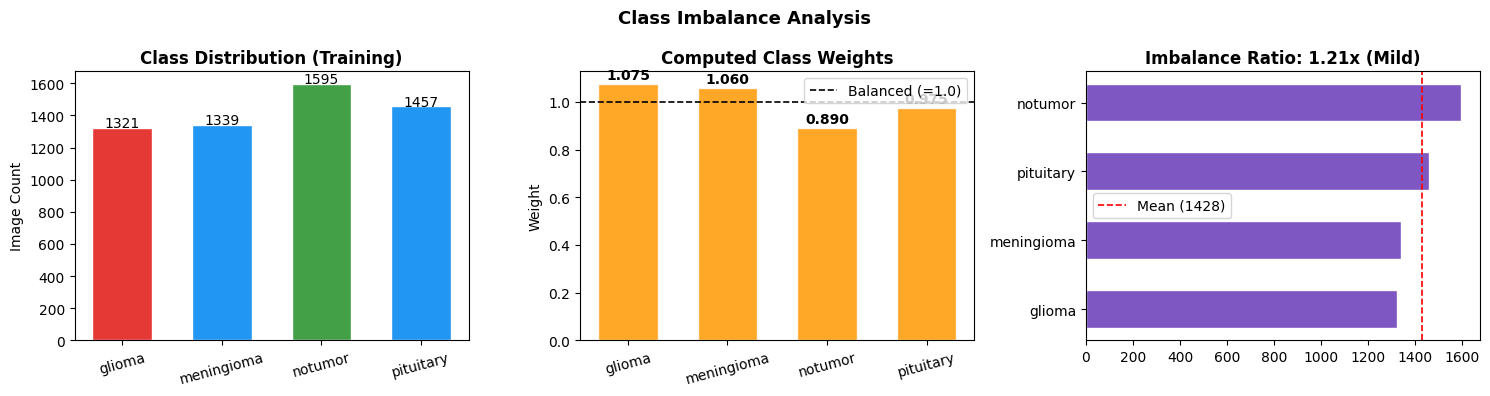


Class              Count        %     Weight  Interpretation
----------------------------------------------------------------------
glioma              1321    23.1%     1.0749  balanced
meningioma          1339    23.4%     1.0604  balanced
notumor             1595    27.9%     0.8902  down-weighted
pituitary           1457    25.5%     0.9745  balanced

Imbalance ratio: 1.21x


In [8]:
def compute_class_weights(labels):
    counts = Counter(labels.tolist())
    total  = sum(counts.values())
    w = np.array([1.0 / (counts.get(c, 1) / total) for c in range(num_classes)])
    w = w * len(w) / (w.sum() + 1e-12)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

def plot_class_distribution_and_weights(labels, class_names):
    counts     = Counter(labels.tolist())
    weights    = compute_class_weights(labels).cpu().numpy()
    count_vals = [counts[i] for i in range(len(class_names))]
    total      = sum(count_vals)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    colors = ["#E53935" if count_vals[i] == min(count_vals)
              else "#43A047" if count_vals[i] == max(count_vals)
              else "#2196F3" for i in range(len(class_names))]
    bars = axes[0].bar(class_names, count_vals, color=colors, edgecolor="white", width=0.6)
    axes[0].set_title("Class Distribution (Training)", fontweight="bold")
    axes[0].set_ylabel("Image Count")
    for bar, val in zip(bars, count_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha="center", fontsize=10)
    axes[0].tick_params(axis="x", rotation=15)

    w_colors = ["#E53935" if w > 1.2 else "#43A047" if w < 0.8 else "#FF9800"
                for w in weights]
    axes[1].bar(class_names, weights, color=w_colors, edgecolor="white", width=0.6, alpha=0.85)
    axes[1].axhline(y=1.0, color="black", linestyle="--", linewidth=1.2, label="Balanced (=1.0)")
    axes[1].set_title("Computed Class Weights", fontweight="bold")
    axes[1].set_ylabel("Weight"); axes[1].legend()
    for i, (name, w) in enumerate(zip(class_names, weights)):
        axes[1].text(i, w + 0.02, f"{w:.3f}", ha="center", fontsize=10, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=15)

    imbalance_ratio = max(count_vals) / min(count_vals)
    sorted_idx = np.argsort(count_vals)
    axes[2].barh([class_names[i] for i in sorted_idx],
                  [count_vals[i] for i in sorted_idx],
                  color="#7E57C2", edgecolor="white", height=0.55)
    axes[2].axvline(x=total/len(count_vals), color="red", linestyle="--",
                    linewidth=1.2, label=f"Mean ({total//len(count_vals)})")
    severity = "Severe" if imbalance_ratio > 2 else "Moderate" if imbalance_ratio > 1.3 else "Mild"
    axes[2].set_title(f"Imbalance Ratio: {imbalance_ratio:.2f}x ({severity})", fontweight="bold")
    axes[2].legend()

    plt.suptitle("Class Imbalance Analysis", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    print("\n" + "="*70)
    print(f"{'Class':15s} {'Count':>8} {'%':>8} {'Weight':>10}  Interpretation")
    print("-"*70)
    for i, cls in enumerate(class_names):
        pct    = 100 * count_vals[i] / total
        interp = "UP-weighted" if weights[i] > 1.1 else "down-weighted" if weights[i] < 0.9 else "balanced"
        print(f"{cls:15s} {count_vals[i]:>8d} {pct:>7.1f}% {weights[i]:>10.4f}  {interp}")
    print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")

plot_class_distribution_and_weights(train_labels, class_names)


## 9. Sample images

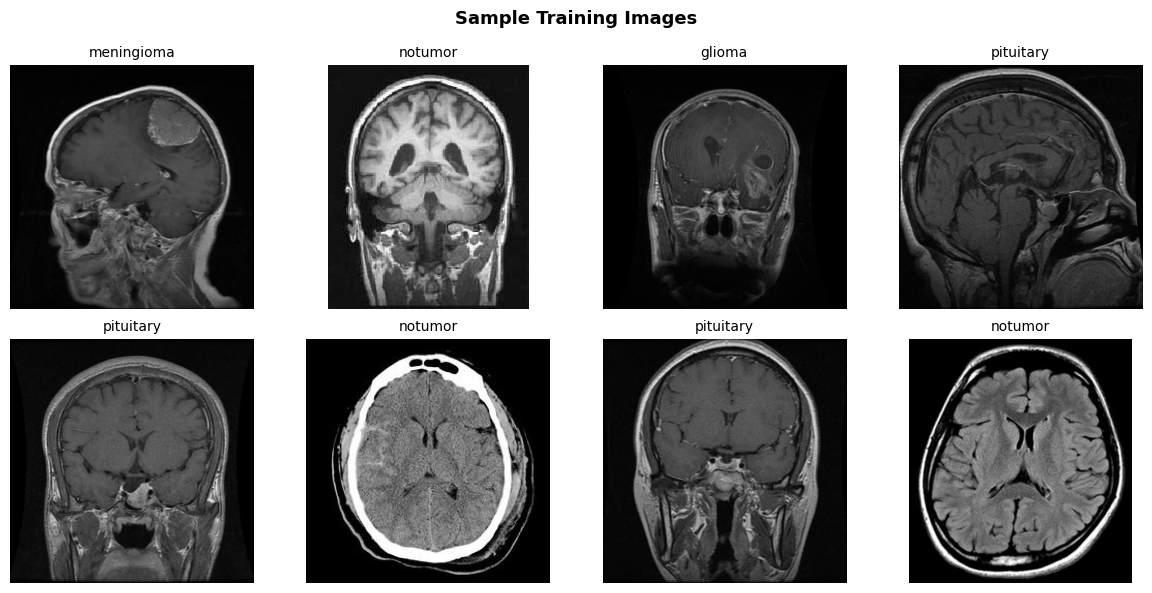

In [9]:
def show_samples(paths, labels, class_names, title=""):
    idxs = np.random.choice(len(paths), size=8, replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, idx in enumerate(idxs):
        axes.ravel()[i].imshow(Image.open(paths[idx]).convert("RGB"))
        axes.ravel()[i].set_title(class_names[labels[idx]], fontsize=10)
        axes.ravel()[i].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

show_samples(train_paths, train_labels, class_names, title="Sample Training Images")


## 10. Swin-Tiny model builder


In [10]:
def build_swin_tiny(num_classes, fine_tune_at=2, dropout_rates=(0.3, 0.2)):
    """
    Swin-Tiny with ImageNet-1K pretrained weights.

    Swin features layout (8 children):
      [0] PatchEmbedding
      [1] BasicLayer  (stage 1)
      [2] PatchMerging
      [3] BasicLayer  (stage 2)
      [4] PatchMerging
      [5] BasicLayer  (stage 3)
      [6] PatchMerging
      [7] BasicLayer  (stage 4)  ← fine_tune_at=2 unfreezes [6] and [7]

    Head uses LayerNorm + GELU — standard transformer practice.
    """
    model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)

    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze last fine_tune_at * 2 feature children (stage + merge pairs)
    feature_layers = list(model.features.children())
    for layer in feature_layers[-(fine_tune_at * 2):]:
        for p in layer.parameters():
            p.requires_grad = True

    # Always unfreeze the final LayerNorm
    for p in model.norm.parameters():
        p.requires_grad = True

    # Replace classification head
    in_feat = model.head.in_features
    model.head = nn.Sequential(
        nn.LayerNorm(in_feat),          # transformer-style normalisation
        nn.Linear(in_feat, 256),
        nn.GELU(),                      # GELU preferred over ReLU in transformers
        nn.Dropout(dropout_rates[0]),
        nn.Linear(256, num_classes),
    )
    return model.to(DEVICE)


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


_m = build_swin_tiny(4, FINE_TUNE_AT, tuple(DROPOUT_RATES))   # 4 = placeholder
_tot, _trn = count_params(_m)
print(f"Swin-Tiny Parameters:")
print(f"  Total     : {_tot:,}")
print(f"  Trainable : {_trn:,}  ({100*_trn/_tot:.1f}%)")
del _m


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 172MB/s]


Swin-Tiny Parameters:
  Total     : 27,718,782
  Trainable : 26,522,940  (95.7%)


## 11. Best checkpoint tracker

In [11]:
class BestCheckpoint:
    """Single source of truth — tracks best epoch AND handles early stopping."""
    def __init__(self, patience=8, min_delta=1e-4):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best        = None
        self.counter     = 0
        self.should_stop = False

    def update(self, score, model, payload):
        if (self.best is None) or (score > self.best["score"] + self.min_delta):
            self.best = {
                "score":   score,
                "weights": {k: v.detach().cpu().clone()
                            for k, v in model.state_dict().items()},
                **payload,
            }
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def restore(self, model):
        if self.best is not None:
            model.load_state_dict(self.best["weights"])
        return model

print(" BestCheckpoint ready")


 BestCheckpoint ready


## 12. Metric utilities + Bootstrap CI

In [12]:
def softmax_np(logits):
    e = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def get_metrics(y_true, y_pred, probs=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    m = {
        "acc":   accuracy_score(y_true, y_pred),
        "prec":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "rec":   recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":    f1_score(y_true, y_pred, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "mcc":   matthews_corrcoef(y_true, y_pred),
    }
    if probs is not None:
        try:
            m["auc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        except Exception:
            m["auc"] = np.nan
    else:
        m["auc"] = np.nan
    return m

def get_clinical_metrics(y_true, y_pred):
    results = {}
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    for i, cls in enumerate(class_names):
        tp = int(np.sum((y_true == i) & (y_pred == i)))
        tn = int(np.sum((y_true != i) & (y_pred != i)))
        fp = int(np.sum((y_true != i) & (y_pred == i)))
        fn = int(np.sum((y_true == i) & (y_pred != i)))
        results[cls] = {
            "sensitivity": round(float(tp / (tp + fn + 1e-8)), 4),
            "specificity": round(float(tn / (tn + fp + 1e-8)), 4),
            "PPV":         round(float(tp / (tp + fp + 1e-8)), 4),
            "NPV":         round(float(tn / (tn + fn + 1e-8)), 4),
            "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        }
    return results

def bootstrap_ci(y_true, y_pred, probs=None, n=1000, seed=42):
    """Bootstrap 95% CI for all metrics."""
    rng = np.random.RandomState(seed)
    N   = len(y_true)
    cis = {"acc": [], "prec": [], "rec": [], "f1": [],
           "kappa": [], "mcc": [], "auc": []}

    for _ in range(n):
        idx = rng.choice(N, N, replace=True)
        yt  = np.asarray(y_true)[idx]
        yp  = np.asarray(y_pred)[idx]
        pp  = np.asarray(probs)[idx] if probs is not None else None
        if len(np.unique(yt)) < num_classes:
            continue
        m = get_metrics(yt, yp, pp)
        for k in cis:
            cis[k].append(m.get(k, np.nan))

    out = {}
    for k, vals in cis.items():
        arr = np.array(vals, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            out[k] = {"mean": np.nan, "lower": np.nan, "upper": np.nan}
        else:
            out[k] = {
                "mean":  float(np.mean(arr)),
                "lower": float(np.percentile(arr, 2.5)),
                "upper": float(np.percentile(arr, 97.5)),
            }
    return out

def normalize_cm_safe(cm):
    """Zero-safe row-wise normalization."""
    cm_sum = cm.sum(axis=1, keepdims=True)
    return np.divide(cm.astype(float), cm_sum,
                     out=np.zeros_like(cm, dtype=float),
                     where=cm_sum != 0)

print("Metric utilities ready")


Metric utilities ready


## 13. Plot utilities

In [13]:
def plot_history(history, fold):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train", color="#2196F3")
    axes[0].plot(history["val_loss"],   label="Val",   color="#FF5722")
    axes[0].set_title(f"{EXPERIMENT} Fold {fold} — Loss"); axes[0].legend()
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].plot(history["train_acc"], label="Train", color="#2196F3")
    axes[1].plot(history["val_acc"],   label="Val",   color="#FF5722")
    axes[1].set_title(f"{EXPERIMENT} Fold {fold} — Accuracy"); axes[1].legend()
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    plt.tight_layout(); plt.show()

def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = normalize_cm_safe(cm)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, fmt, t in zip(axes, [cm, cm_norm], ["d", ".2f"],
                                 [f"{title} (Raw)", f"{title} (Normalized)"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                    xticklabels=class_names, yticklabels=class_names)
        ax.set_title(t); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()

def plot_roc(y_true, probs, title_suffix=""):
    yb = label_binarize(y_true, classes=list(range(num_classes)))
    plt.figure(figsize=(7, 6))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(yb[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    fpr_m, tpr_m, _ = roc_curve(yb.ravel(), probs.ravel())
    plt.plot(fpr_m, tpr_m, "k--", label=f"micro (AUC={auc(fpr_m,tpr_m):.3f})")
    plt.plot([0,1],[0,1],"gray"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC — {title_suffix}"); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

def plot_clinical_table(clinical_metrics, title="Clinical Metrics"):
    rows = []
    for cls, m in clinical_metrics.items():
        rows.append([cls, f"{m['sensitivity']:.4f}", f"{m['specificity']:.4f}",
                     f"{m['PPV']:.4f}", f"{m['NPV']:.4f}"])
    cols = ["Class", "Sensitivity", "Specificity", "PPV", "NPV"]
    fig, ax = plt.subplots(figsize=(10, 2 + len(rows)*0.5))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.8)
    for j in range(len(cols)):
        tbl[(0, j)].set_facecolor("#2196F3")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(rows)+1):
        for j in range(len(cols)):
            tbl[(i, j)].set_facecolor("#f0f4ff" if i%2==0 else "white")
    plt.title(title, fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout(); plt.show()


def plot_roc_per_class(y_true, probs, title_suffix="", save_dir=None):
    """Per-class ROC curves as individual subplot grid — publication-ready."""
    yb = label_binarize(y_true, classes=list(range(num_classes)))
    cols = min(num_classes, 4)
    rows = (num_classes + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes_flat = axes.ravel() if hasattr(axes, "ravel") else [axes]

    aucs = []
    for i, (cls, ax) in enumerate(zip(class_names, axes_flat)):
        fpr, tpr, _ = roc_curve(yb[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color="#1565C0", lw=2,
                label=f"AUC = {roc_auc:.3f}")
        ax.fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
        ax.set_xlabel("False Positive Rate", fontsize=9)
        ax.set_ylabel("True Positive Rate", fontsize=9)
        ax.set_title(f"Class: {cls}", fontsize=10, fontweight="bold")
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[num_classes:]:
        ax.axis("off")

    macro_auc = float(roc_auc_score(yb, probs, multi_class="ovr", average="macro"))
    plt.suptitle(
        f"Per-Class ROC Curves — {title_suffix}\nMacro AUC = {macro_auc:.4f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, f"roc_per_class_{title_suffix.replace(' ', '_')}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  ROC figure saved → {path}")
    plt.show()
    return aucs

print(" Plot utilities ready")


 Plot utilities ready


## 14. Training function (one fold)

In [14]:
def train_one_fold(train_loader, val_loader, model, criterion, optimizer, fold_no):
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": [],
               "train_f1_ema": [], "val_f1": []}
    # CosineAnnealingWarmRestarts works better than ReduceLROnPlateau for Swin
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=LR_MIN
    )
    scaler  = GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda")
    )
    tracker = BestCheckpoint(patience=PATIENCE)
    train_f1_ema = None

    fold_start = time.time()

    for epoch in range(EPOCHS):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        tr_preds, tr_labels = [], []

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            if USE_AMP and DEVICE.type == "cuda":
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, lbls)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                out  = model(imgs)
                loss = criterion(out, lbls)
                loss.backward()
                optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += imgs.size(0)
            tr_preds.extend(out.argmax(1).cpu().numpy())
            tr_labels.extend(lbls.cpu().numpy())

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        val_preds, val_lbls_all, val_logits = [], [], []

        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, lbls)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == lbls).sum().item()
                v_total   += imgs.size(0)
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_lbls_all.extend(lbls.cpu().numpy())
                val_logits.append(out.cpu().numpy())

        train_loss = run_loss / max(total, 1)
        train_acc  = correct  / max(total, 1)
        val_loss   = v_loss   / max(v_total, 1)
        val_acc    = v_correct / max(v_total, 1)

        probs_np = softmax_np(np.concatenate(val_logits))
        val_m    = get_metrics(val_lbls_all, val_preds, probs_np)
        tr_f1    = f1_score(tr_labels, tr_preds, average="macro", zero_division=0)

        train_f1_ema = tr_f1 if train_f1_ema is None else (
            0.3 * tr_f1 + 0.7 * train_f1_ema  # EMA smoothing (alpha=0.3)
            )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1_ema"].append(train_f1_ema)
        history["val_f1"].append(val_m["f1"])

        print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
              f"Train L/A: {train_loss:.4f}/{train_acc:.4f} | "
              f"Val L/A: {val_loss:.4f}/{val_acc:.4f} | "
              f"ValF1: {val_m['f1']:.4f} | ValAUC: {val_m['auc']:.4f}")

        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(epoch + fold_no / KFOLDS)  # CosineAnnealingWarmRestarts step
        new_lr = optimizer.param_groups[0]["lr"]
        if abs(new_lr - old_lr) > 1e-10:
            print(f"  [LR] {old_lr:.2e} → {new_lr:.2e}")

        payload = {
            "epoch":        epoch + 1,
            "y_true":       np.array(val_lbls_all),
            "y_pred":       np.array(val_preds),
            "probs":        probs_np,
            "train_acc":    train_acc,
            "train_f1_ema": train_f1_ema,
            "val_acc":      val_acc,
            "val_f1":       val_m["f1"],
            "val_loss":     val_loss,
        }
        if tracker.update(val_m[BEST_METRIC], model, payload):
            print(f"  [EarlyStopping] Best {BEST_METRIC.upper()}: "
                  f"{tracker.best['score']:.4f} @ epoch {tracker.best['epoch']}")
            break

    fold_time = time.time() - fold_start
    print(f"  Training time: {fold_time/60:.1f} min")
    tracker.restore(model)
    return history, tracker.best, model, fold_time

print(" Training function ready")


 Training function ready


## 15. Run 5-Fold Cross Validation

⏱️ **This takes ~2-3 hours on GPU**


========================= Fold 1/5 =========================
Epoch   1/60 | Train L/A: 0.4000/0.8728 | Val L/A: 0.1176/0.9615 | ValF1: 0.9603 | ValAUC: 0.9966
  [LR] 5.00e-05 → 5.00e-05
Epoch   2/60 | Train L/A: 0.1340/0.9580 | Val L/A: 0.1021/0.9650 | ValF1: 0.9640 | ValAUC: 0.9980
  [LR] 5.00e-05 → 4.82e-05
Epoch   3/60 | Train L/A: 0.0812/0.9744 | Val L/A: 0.1033/0.9685 | ValF1: 0.9680 | ValAUC: 0.9984
  [LR] 4.82e-05 → 4.43e-05
Epoch   4/60 | Train L/A: 0.0532/0.9829 | Val L/A: 0.0736/0.9843 | ValF1: 0.9836 | ValAUC: 0.9983
  [LR] 4.43e-05 → 3.84e-05
Epoch   5/60 | Train L/A: 0.0444/0.9851 | Val L/A: 0.0894/0.9738 | ValF1: 0.9727 | ValAUC: 0.9987
  [LR] 3.84e-05 → 3.13e-05
Epoch   6/60 | Train L/A: 0.0318/0.9904 | Val L/A: 0.0594/0.9878 | ValF1: 0.9876 | ValAUC: 0.9989
  [LR] 3.13e-05 → 2.35e-05
Epoch   7/60 | Train L/A: 0.0223/0.9939 | Val L/A: 0.0682/0.9834 | ValF1: 0.9831 | ValAUC: 0.9987
  [LR] 2.35e-05 → 1.59e-05
Epoch   8/60 | Train L/A: 0.0198/0.9937 | Val L/A: 0.0604/0.987

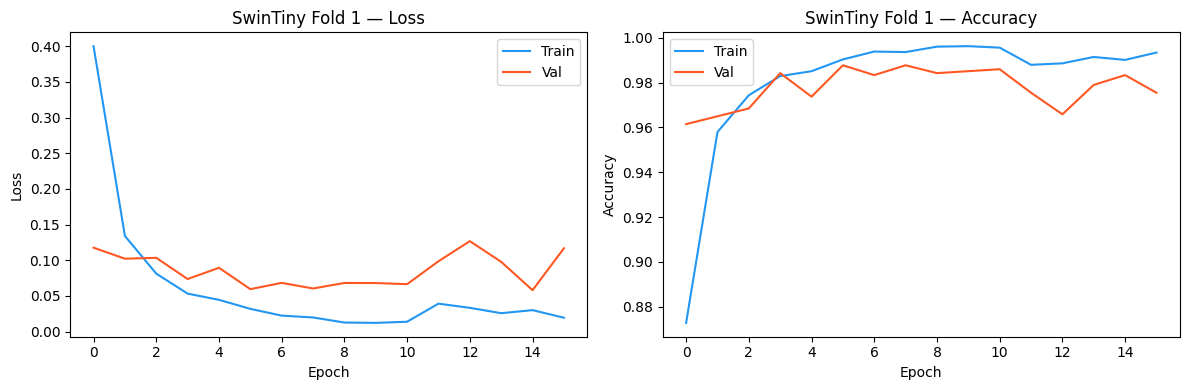


Classification Report — Fold 1:
              precision    recall  f1-score   support

      glioma     0.9888    1.0000    0.9944       265
  meningioma     0.9848    0.9738    0.9793       267
     notumor     0.9968    0.9843    0.9905       319
   pituitary     0.9797    0.9932    0.9864       292

    accuracy                         0.9878      1143
   macro avg     0.9876    0.9878    0.9876      1143
weighted avg     0.9878    0.9878    0.9877      1143

Fold 1: Acc=0.9878 | F1=0.9876 | AUC=0.9989 | Kappa=0.9836 | MCC=0.9837


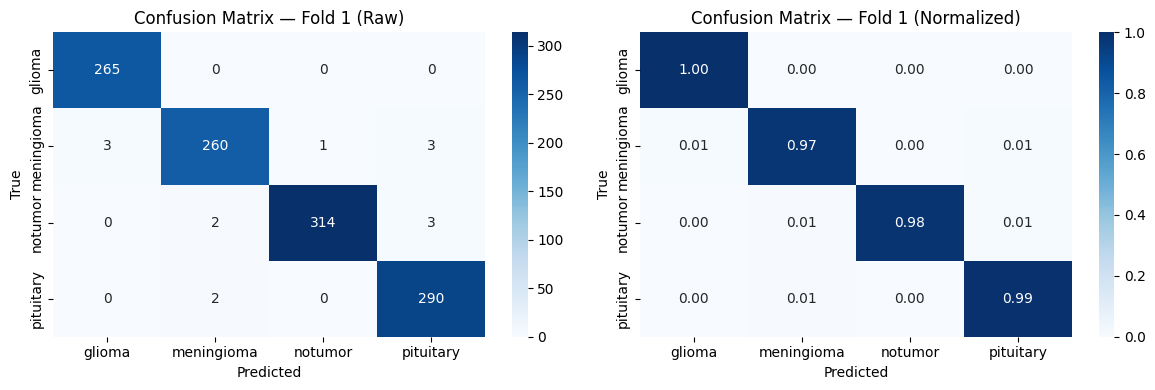

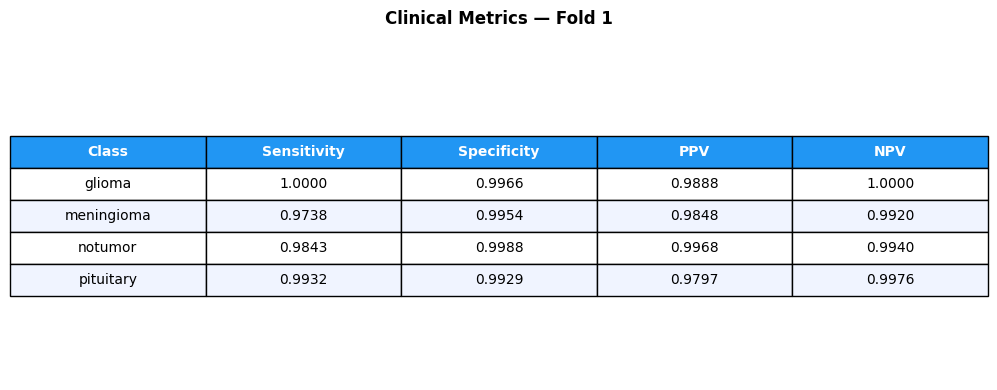

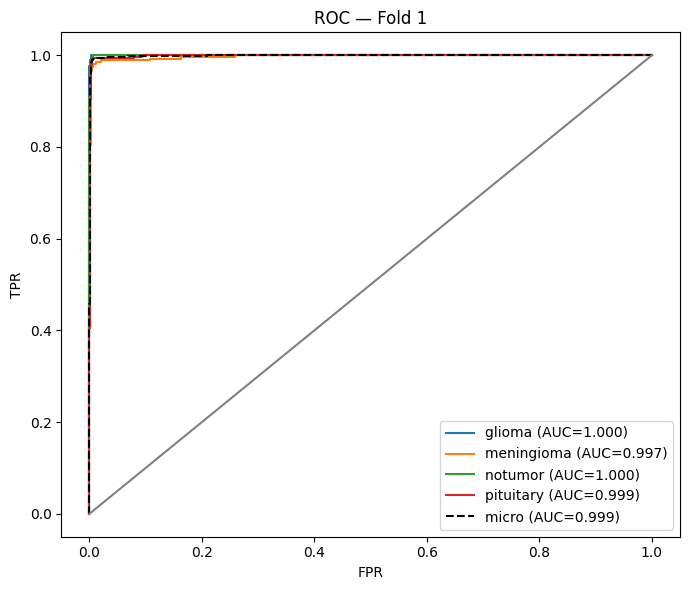

  Checkpoint → checkpoints_SwinTiny_Dataset1/SwinTiny_fold1.pt
  New best fold! F1 = 0.9876

========================= Fold 2/5 =========================
Epoch   1/60 | Train L/A: 0.4082/0.8696 | Val L/A: 0.1427/0.9510 | ValF1: 0.9480 | ValAUC: 0.9969
  [LR] 5.00e-05 → 4.98e-05
Epoch   2/60 | Train L/A: 0.1382/0.9569 | Val L/A: 0.1289/0.9554 | ValF1: 0.9538 | ValAUC: 0.9980
  [LR] 4.98e-05 → 4.76e-05
Epoch   3/60 | Train L/A: 0.0786/0.9755 | Val L/A: 0.0903/0.9755 | ValF1: 0.9747 | ValAUC: 0.9979
  [LR] 4.76e-05 → 4.32e-05
Epoch   4/60 | Train L/A: 0.0571/0.9823 | Val L/A: 0.0589/0.9834 | ValF1: 0.9824 | ValAUC: 0.9993
  [LR] 4.32e-05 → 3.71e-05
Epoch   5/60 | Train L/A: 0.0340/0.9888 | Val L/A: 0.0743/0.9816 | ValF1: 0.9805 | ValAUC: 0.9983
  [LR] 3.71e-05 → 2.97e-05
Epoch   6/60 | Train L/A: 0.0336/0.9884 | Val L/A: 0.0662/0.9843 | ValF1: 0.9834 | ValAUC: 0.9983
  [LR] 2.97e-05 → 2.19e-05
Epoch   7/60 | Train L/A: 0.0238/0.9937 | Val L/A: 0.0679/0.9851 | ValF1: 0.9842 | ValAUC: 0.999

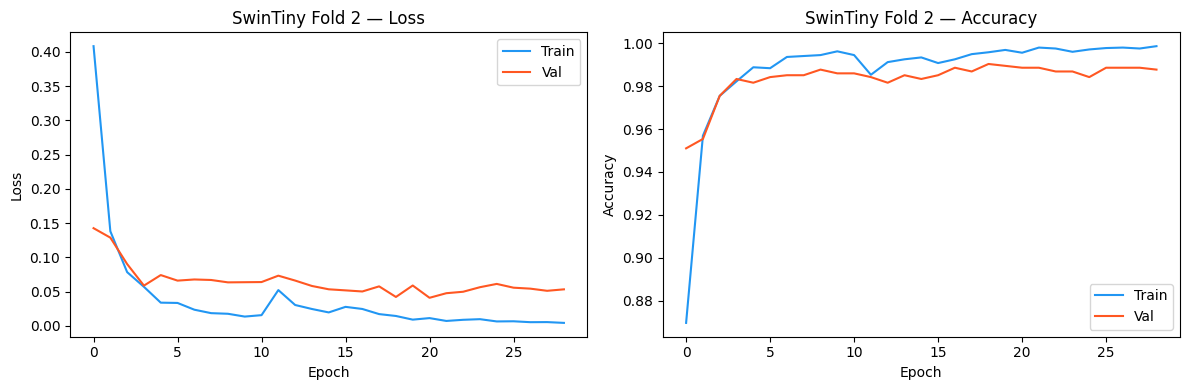


Classification Report — Fold 2:
              precision    recall  f1-score   support

      glioma     0.9740    0.9924    0.9831       264
  meningioma     0.9924    0.9739    0.9831       268
     notumor     0.9969    0.9969    0.9969       319
   pituitary     0.9966    0.9966    0.9966       292

    accuracy                         0.9904      1143
   macro avg     0.9900    0.9899    0.9899      1143
weighted avg     0.9905    0.9904    0.9904      1143

Fold 2: Acc=0.9904 | F1=0.9899 | AUC=0.9997 | Kappa=0.9871 | MCC=0.9872


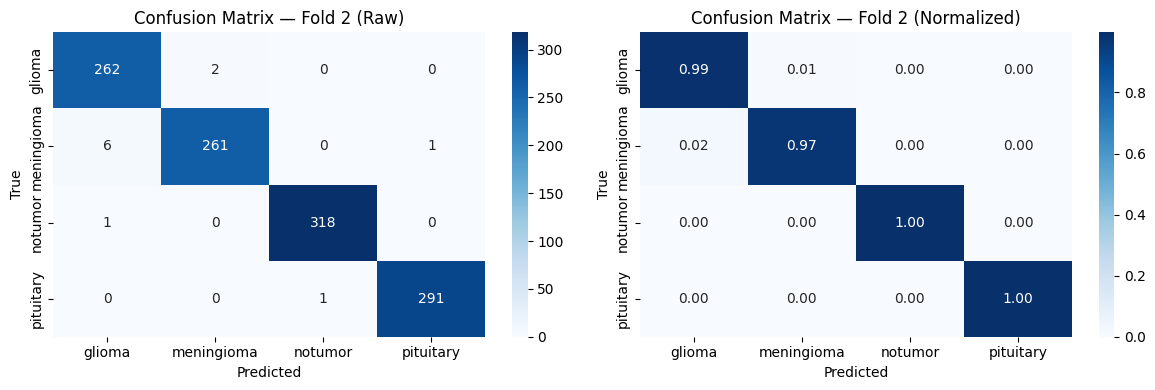

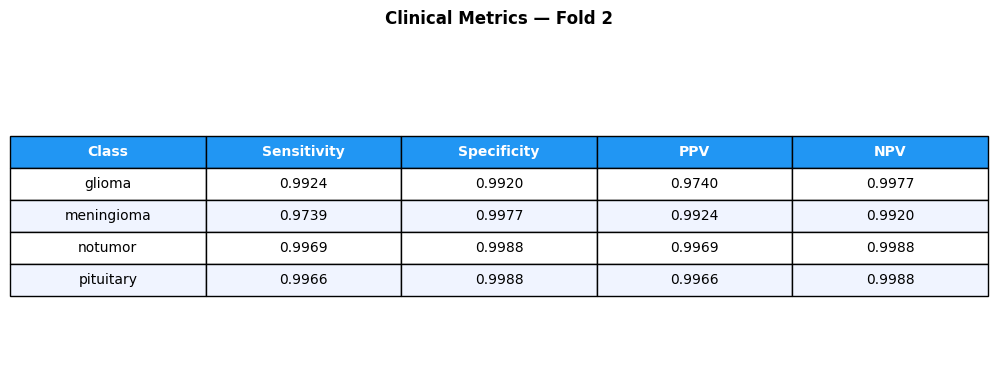

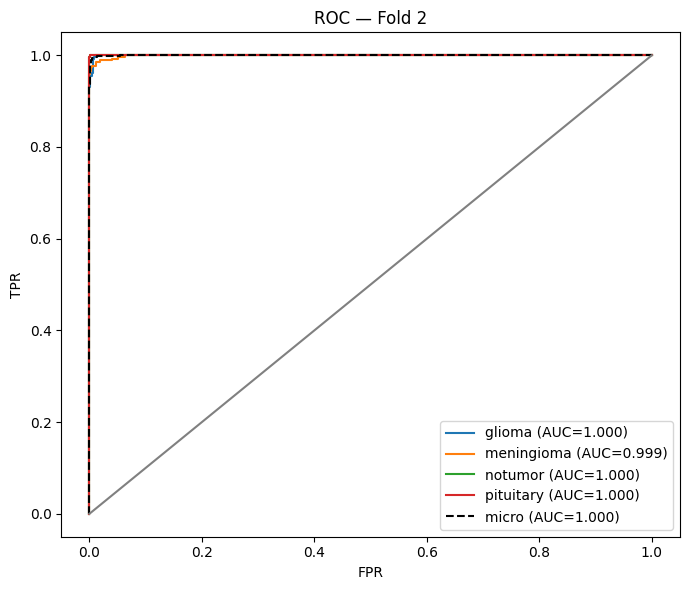

  Checkpoint → checkpoints_SwinTiny_Dataset1/SwinTiny_fold2.pt
  New best fold! F1 = 0.9899

========================= Fold 3/5 =========================
Epoch   1/60 | Train L/A: 0.4144/0.8661 | Val L/A: 0.1411/0.9483 | ValF1: 0.9472 | ValAUC: 0.9971
  [LR] 5.00e-05 → 4.96e-05
Epoch   2/60 | Train L/A: 0.1463/0.9521 | Val L/A: 0.0599/0.9781 | ValF1: 0.9775 | ValAUC: 0.9993
  [LR] 4.96e-05 → 4.69e-05
Epoch   3/60 | Train L/A: 0.0837/0.9746 | Val L/A: 0.0696/0.9755 | ValF1: 0.9754 | ValAUC: 0.9993
  [LR] 4.69e-05 → 4.21e-05
Epoch   4/60 | Train L/A: 0.0633/0.9818 | Val L/A: 0.0584/0.9799 | ValF1: 0.9796 | ValAUC: 0.9995
  [LR] 4.21e-05 → 3.57e-05
Epoch   5/60 | Train L/A: 0.0463/0.9869 | Val L/A: 0.0388/0.9877 | ValF1: 0.9874 | ValAUC: 0.9995
  [LR] 3.57e-05 → 2.82e-05
Epoch   6/60 | Train L/A: 0.0263/0.9912 | Val L/A: 0.0324/0.9904 | ValF1: 0.9902 | ValAUC: 0.9997
  [LR] 2.82e-05 → 2.04e-05
Epoch   7/60 | Train L/A: 0.0228/0.9943 | Val L/A: 0.0343/0.9912 | ValF1: 0.9912 | ValAUC: 0.999

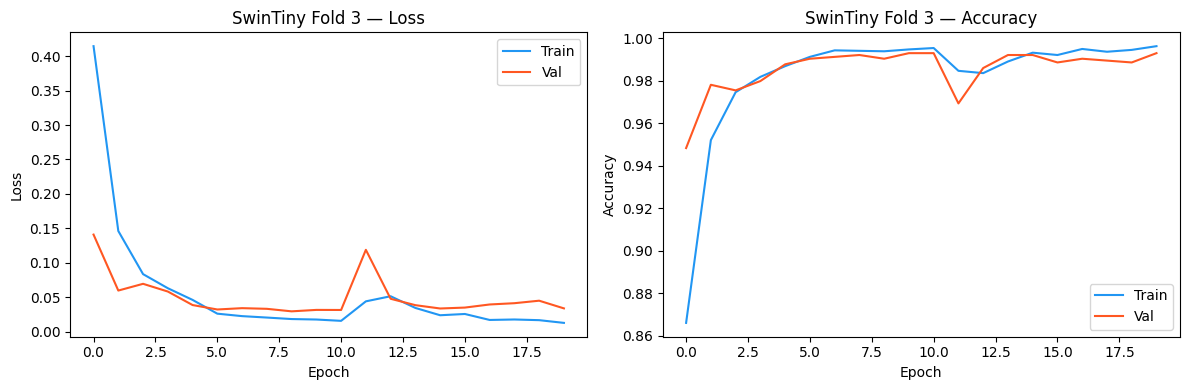


Classification Report — Fold 3:
              precision    recall  f1-score   support

      glioma     0.9925    0.9962    0.9943       264
  meningioma     0.9851    0.9888    0.9870       268
     notumor     0.9938    0.9969    0.9953       319
   pituitary     1.0000    0.9897    0.9948       291

    accuracy                         0.9930      1142
   macro avg     0.9928    0.9929    0.9929      1142
weighted avg     0.9930    0.9930    0.9930      1142

Fold 3: Acc=0.9930 | F1=0.9929 | AUC=0.9998 | Kappa=0.9906 | MCC=0.9906


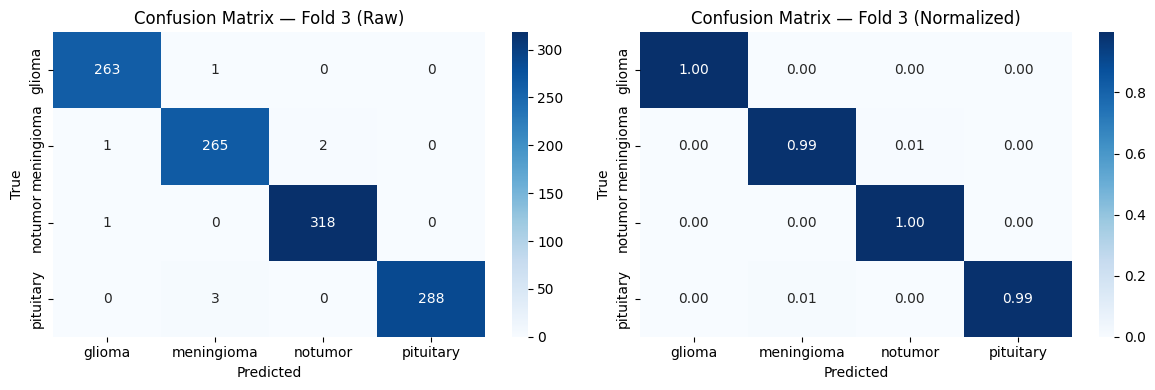

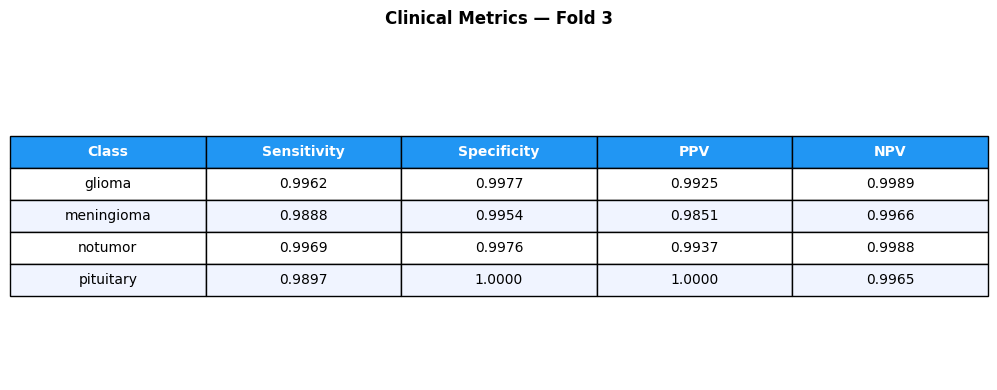

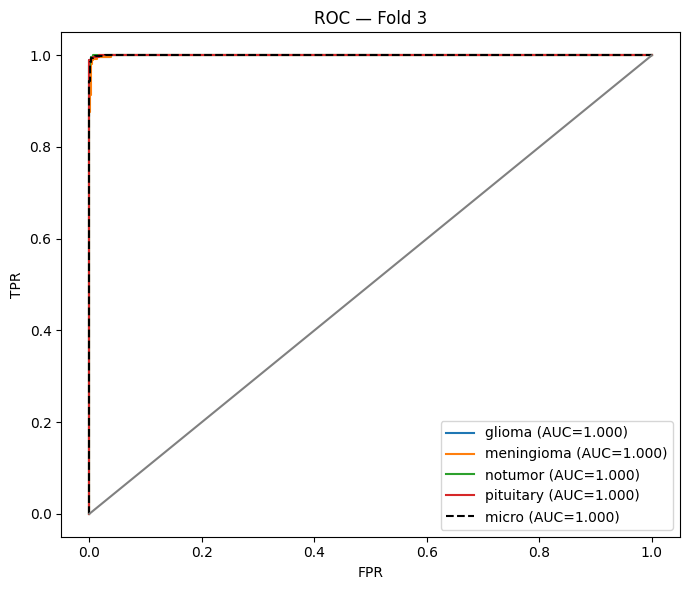

  Checkpoint → checkpoints_SwinTiny_Dataset1/SwinTiny_fold3.pt
  New best fold! F1 = 0.9929

========================= Fold 4/5 =========================
Epoch   1/60 | Train L/A: 0.4197/0.8661 | Val L/A: 0.1145/0.9553 | ValF1: 0.9543 | ValAUC: 0.9979
  [LR] 5.00e-05 → 4.92e-05
Epoch   2/60 | Train L/A: 0.1265/0.9580 | Val L/A: 0.0668/0.9764 | ValF1: 0.9756 | ValAUC: 0.9991
  [LR] 4.92e-05 → 4.61e-05
Epoch   3/60 | Train L/A: 0.0800/0.9744 | Val L/A: 0.0683/0.9799 | ValF1: 0.9793 | ValAUC: 0.9993
  [LR] 4.61e-05 → 4.10e-05
Epoch   4/60 | Train L/A: 0.0571/0.9807 | Val L/A: 0.0619/0.9825 | ValF1: 0.9817 | ValAUC: 0.9995
  [LR] 4.10e-05 → 3.42e-05
Epoch   5/60 | Train L/A: 0.0449/0.9864 | Val L/A: 0.0518/0.9825 | ValF1: 0.9819 | ValAUC: 0.9996
  [LR] 3.42e-05 → 2.66e-05
Epoch   6/60 | Train L/A: 0.0410/0.9886 | Val L/A: 0.0543/0.9842 | ValF1: 0.9836 | ValAUC: 0.9996
  [LR] 2.66e-05 → 1.88e-05
Epoch   7/60 | Train L/A: 0.0219/0.9945 | Val L/A: 0.0568/0.9834 | ValF1: 0.9828 | ValAUC: 0.999

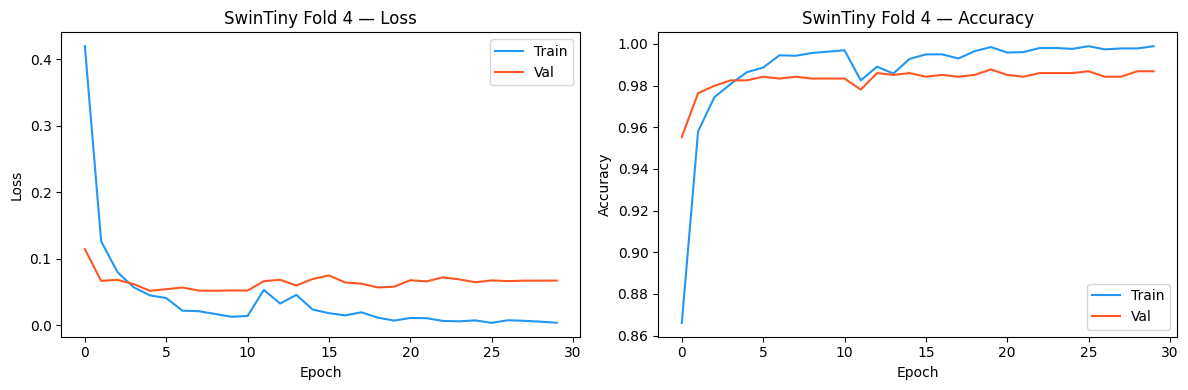


Classification Report — Fold 4:
              precision    recall  f1-score   support

      glioma     0.9886    0.9848    0.9867       264
  meningioma     0.9812    0.9739    0.9775       268
     notumor     0.9969    0.9937    0.9953       319
   pituitary     0.9831    0.9966    0.9898       291

    accuracy                         0.9877      1142
   macro avg     0.9874    0.9873    0.9873      1142
weighted avg     0.9878    0.9877    0.9877      1142

Fold 4: Acc=0.9877 | F1=0.9873 | AUC=0.9997 | Kappa=0.9836 | MCC=0.9836


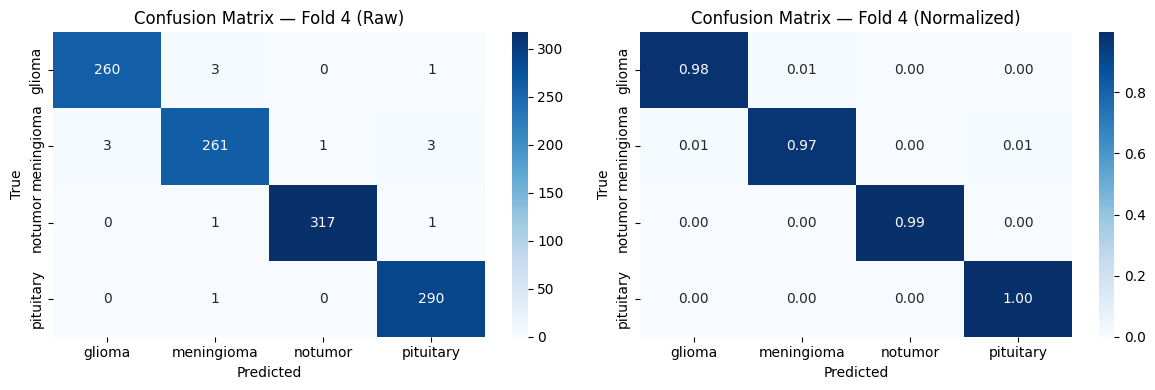

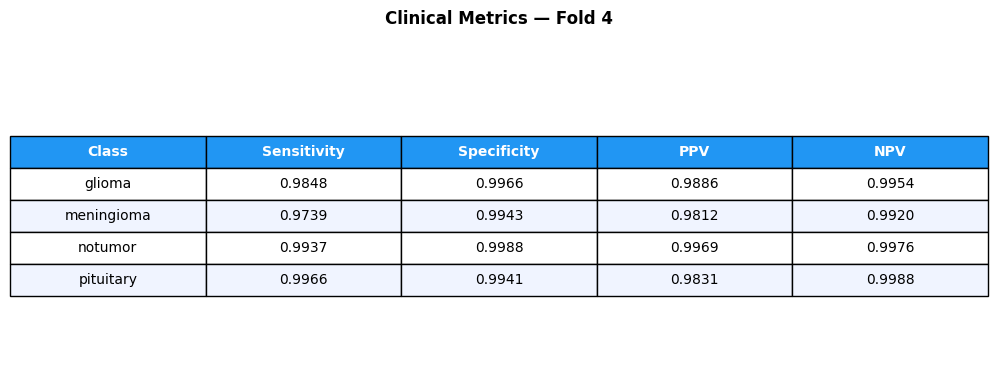

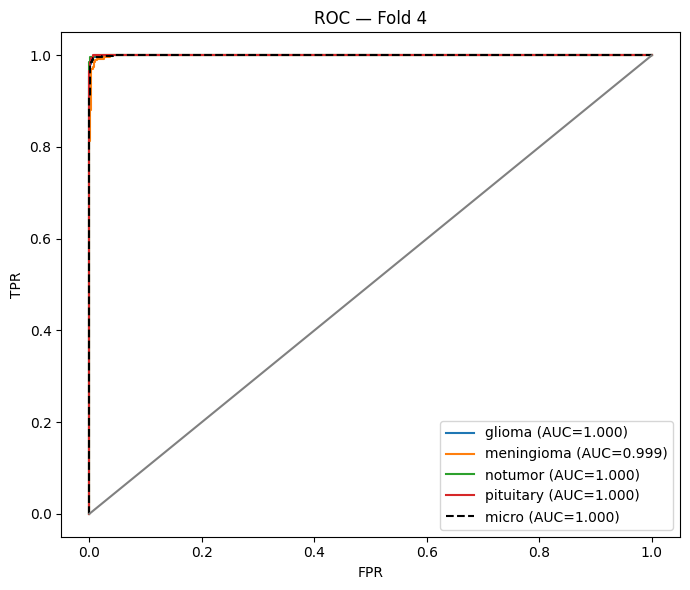

  Checkpoint → checkpoints_SwinTiny_Dataset1/SwinTiny_fold4.pt

========================= Fold 5/5 =========================
Epoch   1/60 | Train L/A: 0.4260/0.8606 | Val L/A: 0.1326/0.9492 | ValF1: 0.9469 | ValAUC: 0.9972
  [LR] 5.00e-05 → 4.88e-05
Epoch   2/60 | Train L/A: 0.1385/0.9549 | Val L/A: 0.0478/0.9851 | ValF1: 0.9846 | ValAUC: 0.9996
  [LR] 4.88e-05 → 4.52e-05
Epoch   3/60 | Train L/A: 0.0832/0.9729 | Val L/A: 0.0926/0.9667 | ValF1: 0.9649 | ValAUC: 0.9995
  [LR] 4.52e-05 → 3.97e-05
Epoch   4/60 | Train L/A: 0.0638/0.9781 | Val L/A: 0.0345/0.9895 | ValF1: 0.9893 | ValAUC: 0.9998
  [LR] 3.97e-05 → 3.28e-05
Epoch   5/60 | Train L/A: 0.0389/0.9886 | Val L/A: 0.0342/0.9895 | ValF1: 0.9892 | ValAUC: 0.9998
  [LR] 3.28e-05 → 2.50e-05
Epoch   6/60 | Train L/A: 0.0324/0.9908 | Val L/A: 0.0389/0.9877 | ValF1: 0.9874 | ValAUC: 0.9998
  [LR] 2.50e-05 → 1.73e-05
Epoch   7/60 | Train L/A: 0.0269/0.9917 | Val L/A: 0.0265/0.9912 | ValF1: 0.9911 | ValAUC: 0.9998
  [LR] 1.73e-05 → 1.04e-05


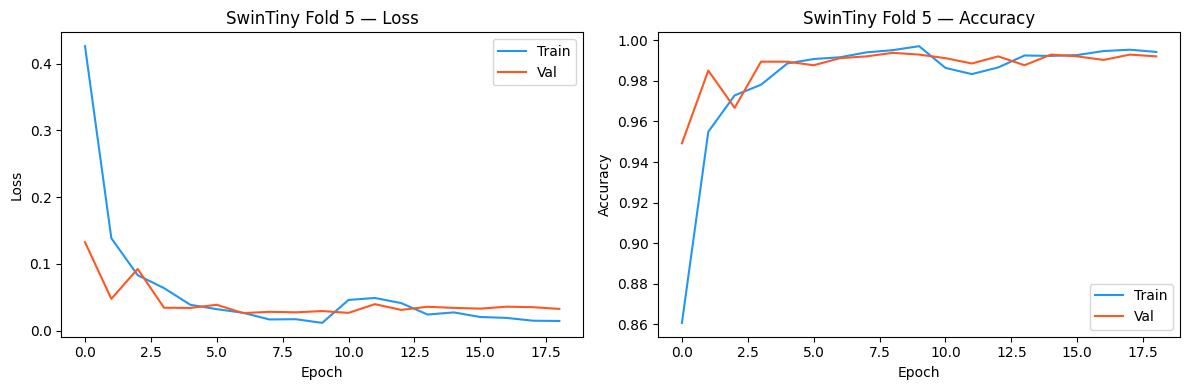


Classification Report — Fold 5:
              precision    recall  f1-score   support

      glioma     0.9962    0.9962    0.9962       264
  meningioma     0.9962    0.9813    0.9887       268
     notumor     0.9969    0.9969    0.9969       319
   pituitary     0.9864    1.0000    0.9932       291

    accuracy                         0.9939      1142
   macro avg     0.9939    0.9936    0.9937      1142
weighted avg     0.9939    0.9939    0.9939      1142

Fold 5: Acc=0.9939 | F1=0.9937 | AUC=0.9998 | Kappa=0.9918 | MCC=0.9918


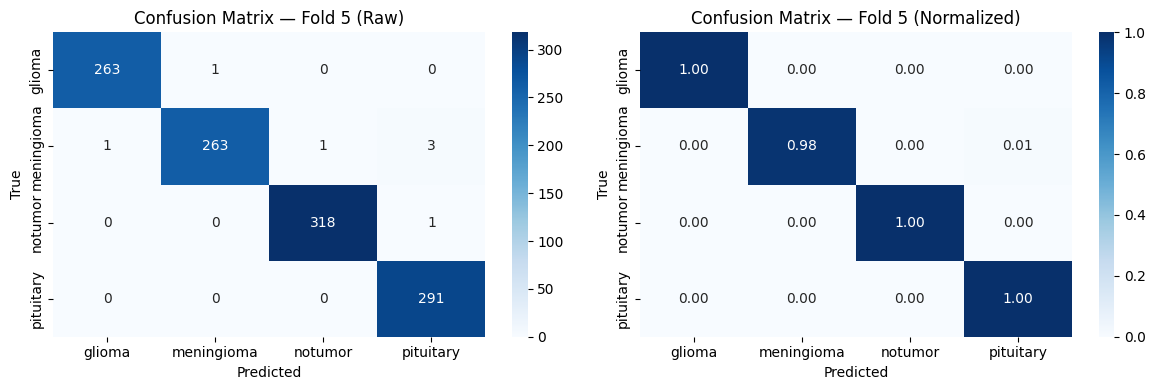

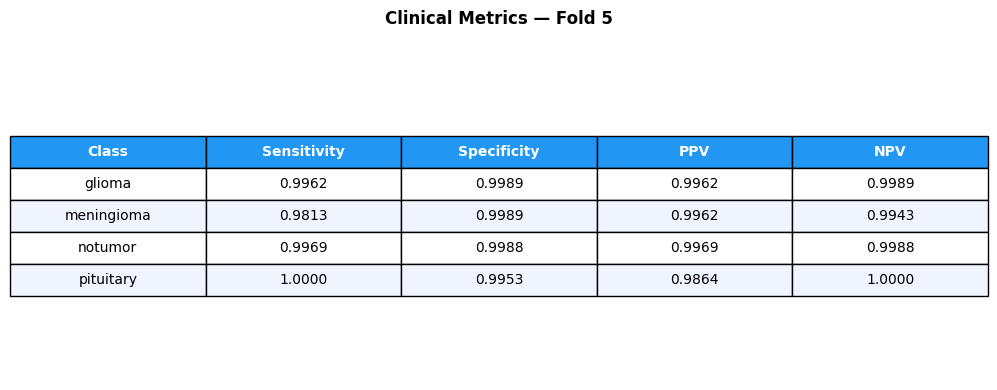

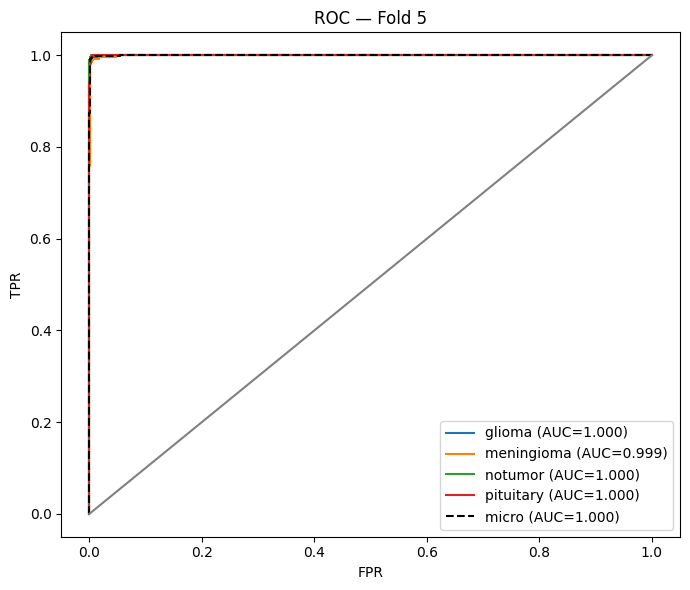

  Checkpoint → checkpoints_SwinTiny_Dataset1/SwinTiny_fold5.pt
  New best fold! F1 = 0.9937

 Cross-validation complete


In [15]:
_m_tmp = build_swin_tiny(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
_tot, _trn = count_params(_m_tmp)
del _m_tmp

MODEL_INFO = {
    "architecture":     "Swin-Tiny",
    "pretrained":       "ImageNet-1K",
    "fine_tune_layers": FINE_TUNE_AT,
    "total_params":     int(_tot),
    "trainable_params": int(_trn),
    "trainable_pct":    round(100 * _trn / _tot, 2),
    "img_size":         IMG_SIZE,
    "batch_size":       BATCH_SIZE,
    "epochs_max":       EPOCHS,
    "patience":         PATIENCE,
    "optimizer":        "AdamW",
    "learning_rate":    LEARNING_RATE,
    "weight_decay":     WEIGHT_DECAY,
    "loss_function":    "CrossEntropyLoss (per-fold class weights)",
    "scheduler":        "CosineAnnealingWarmRestarts(T_0=10, T_mult=2)",
    "dropout_rates":    DROPOUT_RATES,
    "selection_metric": BEST_METRIC,
    "augmentations":    AUG_LIST,
    "seed":             SEED,
    "amp":              USE_AMP,
    "device":           str(DEVICE),
    "pytorch":          torch.__version__,
    "platform":         platform.platform(),
    "bootstrap_n":      BOOTSTRAP_N,
}

kf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
all_fold_metrics = []
best_global_score = -1
best_fold_path    = None
best_fold_no      = None

for fold_no, (tr_idx, val_idx) in enumerate(
        kf.split(train_paths, train_labels), start=1):
    print(f"\n{'='*25} Fold {fold_no}/{KFOLDS} {'='*25}")

    tr_p, val_p = train_paths[tr_idx], train_paths[val_idx]
    tr_l, val_l = train_labels[tr_idx], train_labels[val_idx]

    train_loader = DataLoader(
        BrainTumorDataset(tr_p, tr_l, train_transform),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(
        BrainTumorDataset(val_p, val_l, test_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    set_seed(SEED)  # Reset seed each fold for reproducibility
    model     = build_swin_tiny(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
    cw        = compute_class_weights(tr_l)
    criterion = nn.CrossEntropyLoss(weight=cw)  # label_smoothing removed (was 0.0)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.999),  # Swin paper recommended
        eps=1e-8,
    )

    history, best, model, fold_time = train_one_fold(
        train_loader, val_loader, model, criterion, optimizer, fold_no)

    plot_history(history, fold_no)

    y_true, y_pred, probs = best["y_true"], best["y_pred"], best["probs"]
    metrics = get_metrics(y_true, y_pred, probs)
    metrics.update({
        "best_epoch":     best["epoch"],
        "fold":           fold_no,
        "train_time_sec": fold_time,
        "train_acc":      best["train_acc"],
        "train_f1_ema":   best["train_f1_ema"],
        "val_acc":        best["val_acc"],
        "val_f1":         best["val_f1"],
        "clinical":       get_clinical_metrics(y_true, y_pred),
    })

    print(f"\nClassification Report — Fold {fold_no}:")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                 digits=4, zero_division=0))
    print(f"Fold {fold_no}: Acc={metrics['acc']:.4f} | F1={metrics['f1']:.4f} | "
          f"AUC={metrics['auc']:.4f} | Kappa={metrics['kappa']:.4f} | "
          f"MCC={metrics['mcc']:.4f}")

    plot_cm(y_true, y_pred, title=f"Confusion Matrix — Fold {fold_no}")
    plot_clinical_table(metrics["clinical"], title=f"Clinical Metrics — Fold {fold_no}")
    try:
        plot_roc(y_true, probs, title_suffix=f"Fold {fold_no}")
    except Exception as e:
        print(f"[WARN] ROC plot skipped: {e}")

    ckpt_path = os.path.join(CKPT_DIR, f"{EXPERIMENT}_fold{fold_no}.pt")
    torch.save({
        "state_dict":  model.state_dict(),
        "classes":     class_names,
        "fold":        fold_no,
        "metrics":     metrics,
        "model_info":  MODEL_INFO,
        "run_id":      RUN_ID,
    }, ckpt_path)

    np.save(os.path.join(ARTIFACTS_DIR, f"val_true_fold{fold_no}.npy"),  y_true)
    np.save(os.path.join(ARTIFACTS_DIR, f"val_pred_fold{fold_no}.npy"),  y_pred)
    np.save(os.path.join(ARTIFACTS_DIR, f"val_probs_fold{fold_no}.npy"), probs)

    print(f"  Checkpoint → {ckpt_path}")

    if metrics[BEST_METRIC] > best_global_score:
        best_global_score = metrics[BEST_METRIC]
        best_fold_path    = ckpt_path
        best_fold_no      = fold_no
        print(f"  New best fold! {BEST_METRIC.upper()} = {best_global_score:.4f}")

    all_fold_metrics.append(metrics)

print("\n Cross-validation complete")


## 16. CV Summary

In [16]:
print(f"\n{'='*60}")
print(f"{EXPERIMENT} — 5-Fold CV Summary (Best by: {BEST_METRIC.upper()})")
print(f"{'='*60}")
for key in ["acc", "prec", "rec", "f1", "auc", "kappa", "mcc"]:
    vals = np.array([m[key] for m in all_fold_metrics], dtype=float)
    marker = " ← selection metric" if key == BEST_METRIC else ""
    print(f"  {key:6s}: {np.nanmean(vals):.4f} ± {np.nanstd(vals):.4f}{marker}")

times = [m["train_time_sec"] for m in all_fold_metrics]
print(f"\n  Avg fold time : {np.mean(times)/60:.1f} min")
print(f"  Total time    : {sum(times)/60:.1f} min")
print(f"  Best fold     : Fold {best_fold_no} | {BEST_METRIC.upper()}={best_global_score:.4f}")

print(f"\n{'='*60}")
print("Aggregated Clinical Metrics (Mean ± Std across folds)")
print(f"{'='*60}")
print(f"{'Class':15s} {'Sensitivity':>14} {'Specificity':>14} {'PPV':>10} {'NPV':>10}")
print("-" * 65)
for cls in class_names:
    row = f"{cls:15s}"
    for k in ["sensitivity", "specificity", "PPV", "NPV"]:
        vals = [m["clinical"][cls][k] for m in all_fold_metrics]
        row += f" {np.mean(vals):>7.4f}±{np.std(vals):.4f}"
    print(row)



SwinTiny — 5-Fold CV Summary (Best by: F1)
  acc   : 0.9905 ± 0.0026
  prec  : 0.9903 ± 0.0027
  rec   : 0.9903 ± 0.0026
  f1    : 0.9903 ± 0.0026 ← selection metric
  auc   : 0.9996 ± 0.0003
  kappa : 0.9874 ± 0.0034
  mcc   : 0.9874 ± 0.0034

  Avg fold time : 32.6 min
  Total time    : 163.2 min
  Best fold     : Fold 5 | F1=0.9937

Aggregated Clinical Metrics (Mean ± Std across folds)
Class              Sensitivity    Specificity        PPV        NPV
-----------------------------------------------------------------
glioma           0.9939±0.0052  0.9964±0.0023  0.9880±0.0075  0.9982±0.0016
meningioma       0.9783±0.0060  0.9963±0.0017  0.9879±0.0055  0.9934±0.0018
notumor          0.9937±0.0049  0.9986±0.0005  0.9962±0.0013  0.9976±0.0019
pituitary        0.9952±0.0035  0.9962±0.0027  0.9892±0.0078  0.9983±0.0012


## 17. Overfitting analysis

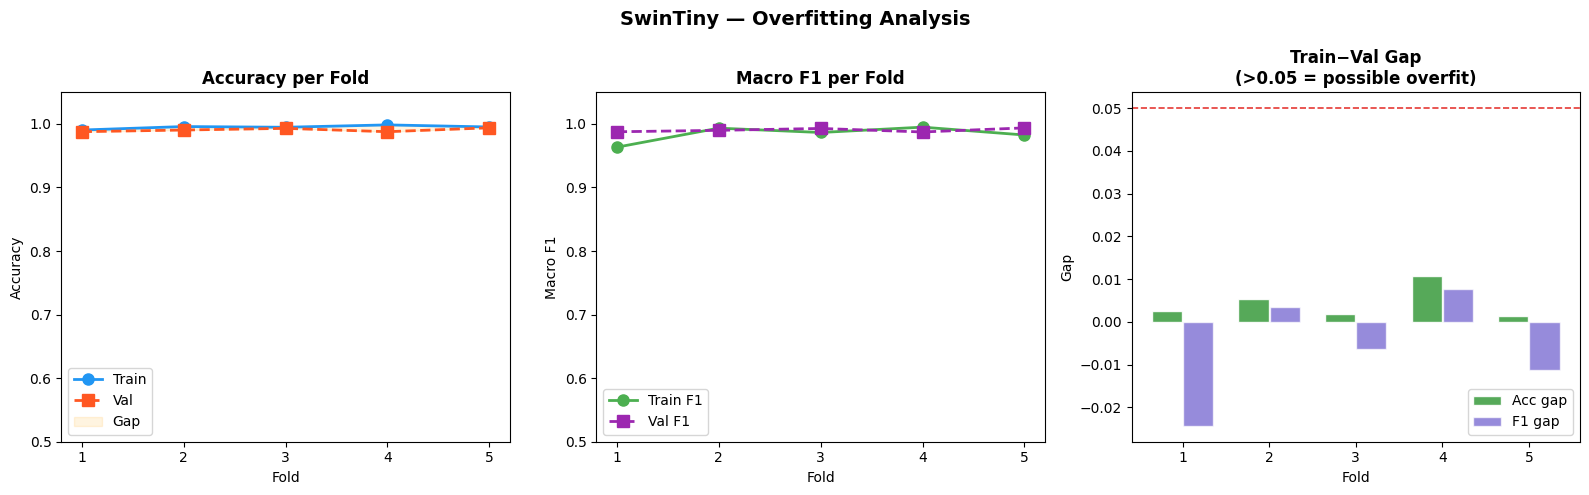


Fold  TrainAcc    ValAcc       Gap  Status
---------------------------------------------
   1    0.9904    0.9878    0.0026  OK
   2    0.9958    0.9904    0.0055  OK
   3    0.9947    0.9930    0.0018  OK
   4    0.9985    0.9877    0.0107  OK
   5    0.9952    0.9939    0.0013  OK

Mean gap: 0.0044 ± 0.0035
 No severe overfitting.


In [17]:
def plot_overfitting_analysis(all_fold_metrics):
    folds      = [m["fold"] for m in all_fold_metrics]
    train_accs = [m["train_acc"] for m in all_fold_metrics]
    val_accs   = [m["acc"] for m in all_fold_metrics]
    train_f1s  = [m["train_f1_ema"] for m in all_fold_metrics]
    val_f1s    = [m["f1"] for m in all_fold_metrics]
    acc_gaps   = [tr - va for tr, va in zip(train_accs, val_accs)]
    f1_gaps    = [tr - va for tr, va in zip(train_f1s, val_f1s)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    x = np.array(folds)

    axes[0].plot(x, train_accs, "o-", label="Train", color="#2196F3", lw=2, ms=8)
    axes[0].plot(x, val_accs,   "s--",label="Val",   color="#FF5722", lw=2, ms=8)
    axes[0].fill_between(x, train_accs, val_accs, alpha=0.12, color="orange", label="Gap")
    axes[0].set_title("Accuracy per Fold", fontweight="bold")
    axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].set_ylim(0.5, 1.05); axes[0].set_xticks(x)

    axes[1].plot(x, train_f1s, "o-", label="Train F1", color="#4CAF50", lw=2, ms=8)
    axes[1].plot(x, val_f1s,   "s--",label="Val F1",   color="#9C27B0", lw=2, ms=8)
    axes[1].set_title("Macro F1 per Fold", fontweight="bold")
    axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Macro F1")
    axes[1].legend(); axes[1].set_ylim(0.5, 1.05); axes[1].set_xticks(x)

    bar_colors = ["#E53935" if g > 0.05 else "#FF9800" if g > 0.02 else "#43A047"
                  for g in acc_gaps]
    axes[2].bar(x - 0.18, acc_gaps, width=0.35, label="Acc gap",
                color=bar_colors, edgecolor="white", alpha=0.9)
    axes[2].bar(x + 0.18, f1_gaps, width=0.35, label="F1 gap",
                color="slateblue", edgecolor="white", alpha=0.7)
    axes[2].axhline(y=0.05, color="#E53935", linestyle="--", lw=1.2)
    axes[2].set_title("Train−Val Gap\n(>0.05 = possible overfit)", fontweight="bold")
    axes[2].set_xlabel("Fold"); axes[2].set_ylabel("Gap")
    axes[2].legend(); axes[2].set_xticks(x)

    plt.suptitle(f"{EXPERIMENT} — Overfitting Analysis",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    print(f"\n{'Fold':>4} {'TrainAcc':>9} {'ValAcc':>9} {'Gap':>9}  Status")
    print("-" * 45)
    for f, tr, va, ag in zip(folds, train_accs, val_accs, acc_gaps):
        status = "OVERFIT" if ag > 0.05 else "mild" if ag > 0.02 else "OK"
        print(f"{f:>4} {tr:>9.4f} {va:>9.4f} {ag:>9.4f}  {status}")
    print(f"\nMean gap: {np.mean(acc_gaps):.4f} ± {np.std(acc_gaps):.4f}")
    if max(acc_gaps) > 0.05:
        print("⚠️  Overfitting detected. Consider more Dropout or weight decay.")
    else:
        print(" No severe overfitting.")

plot_overfitting_analysis(all_fold_metrics)


## 18. Test evaluation + Bootstrap CI

✅ **FIXED** — `weights_only=False` for PyTorch 2.6+



Test Evaluation — Best Fold 5
Loading: checkpoints_SwinTiny_Dataset1/SwinTiny_fold5.pt

SwinTiny — Test Set Performance:
  Acc   = 0.9931
  F1    = 0.9926
  AUC   = 0.9995
  Kappa = 0.9908
  MCC   = 0.9908

              precision    recall  f1-score   support

      glioma     1.0000    0.9800    0.9899       300
  meningioma     0.9775    0.9935    0.9854       306
     notumor     1.0000    1.0000    1.0000       405
   pituitary     0.9934    0.9967    0.9950       300

    accuracy                         0.9931      1311
   macro avg     0.9927    0.9925    0.9926      1311
weighted avg     0.9932    0.9931    0.9931      1311



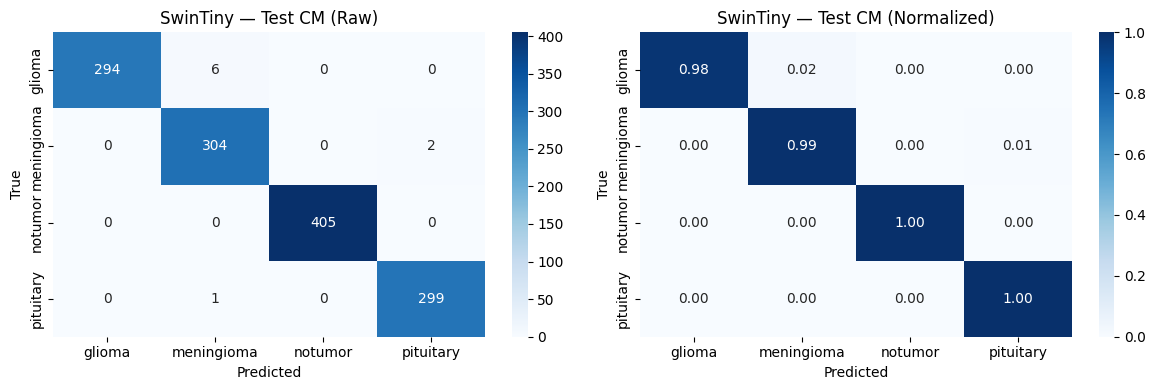

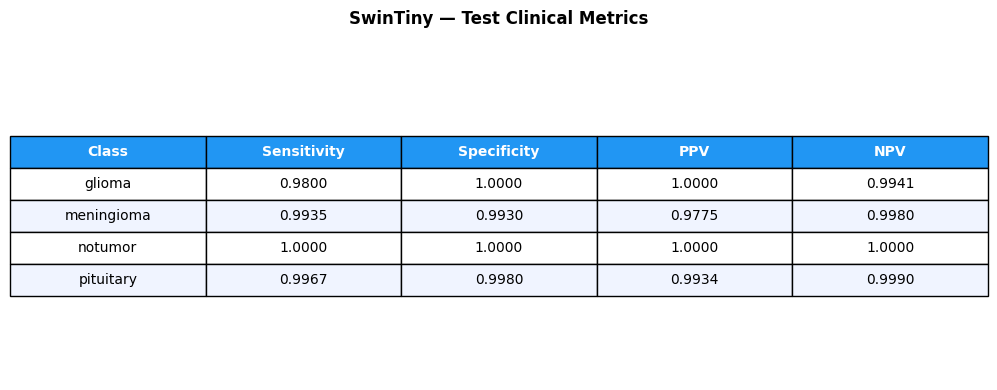

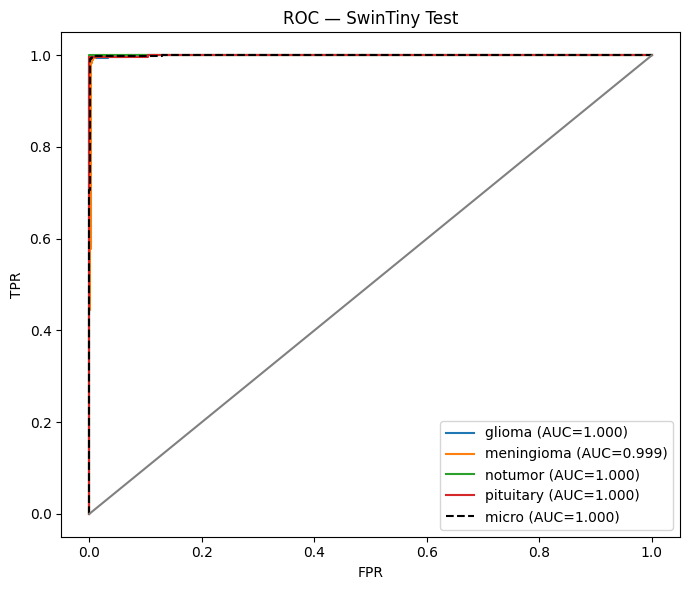

  ROC figure saved → results_SwinTiny_Dataset1/roc_per_class_SwinTiny_Test.png


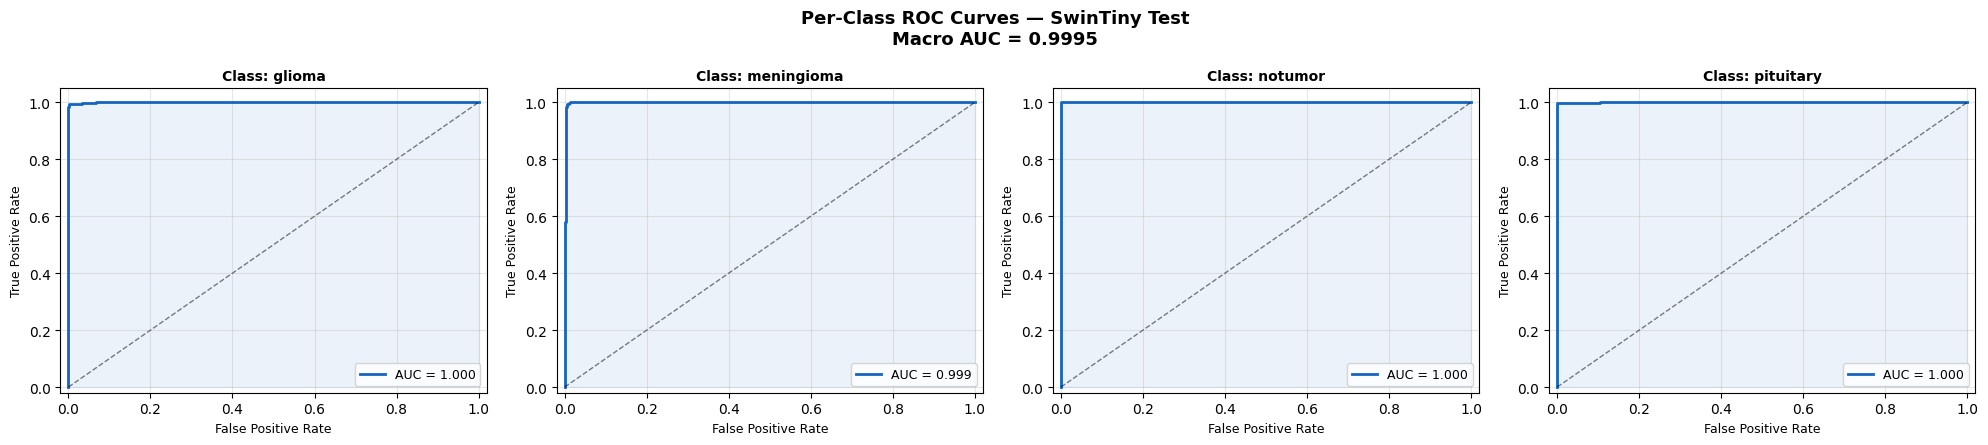


Bootstrap 95% CI (1000 resamples)...

Metric     Estimate                   95% CI
----------------------------------------------
acc          0.9932         [0.9886, 0.9969]
prec         0.9928         [0.9877, 0.9968]
rec          0.9926         [0.9873, 0.9967]
f1           0.9927         [0.9875, 0.9968]
kappa        0.9909         [0.9846, 0.9959]
mcc          0.9909         [0.9847, 0.9959]
auc          0.9995         [0.9988, 1.0000]

 Test artifacts → artifacts_SwinTiny_Dataset1/


In [18]:
# FIXED: weights_only=False added for PyTorch 2.6+ compatibility
test_result   = None
test_preds_np = None
test_true_np  = None
test_probs_np = None

if best_fold_path and test_paths is not None:
    print(f"\n{'='*60}")
    print(f"Test Evaluation — Best Fold {best_fold_no}")
    print(f"{'='*60}")
    print(f"Loading: {best_fold_path}")

    # FIX: weights_only=False
    ckpt  = torch.load(best_fold_path, map_location=DEVICE, weights_only=False)
    model = build_swin_tiny(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    test_loader = DataLoader(
        BrainTumorDataset(test_paths, test_labels, test_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    all_preds, all_lbls, all_logits = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            out = model(imgs.to(DEVICE))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_lbls.extend(lbls.numpy())
            all_logits.append(out.cpu().numpy())

    test_probs_np = softmax_np(np.concatenate(all_logits))
    test_preds_np = np.array(all_preds)
    test_true_np  = np.array(all_lbls)

    test_result = get_metrics(test_true_np, test_preds_np, test_probs_np)
    test_result["clinical"] = get_clinical_metrics(test_true_np, test_preds_np)

    print(f"\n{EXPERIMENT} — Test Set Performance:")
    print(f"  Acc   = {test_result['acc']:.4f}")
    print(f"  F1    = {test_result['f1']:.4f}")
    print(f"  AUC   = {test_result['auc']:.4f}")
    print(f"  Kappa = {test_result['kappa']:.4f}")
    print(f"  MCC   = {test_result['mcc']:.4f}")
    print("\n" + classification_report(test_true_np, test_preds_np,
          target_names=class_names, digits=4, zero_division=0))

    plot_cm(test_true_np, test_preds_np, title=f"{EXPERIMENT} — Test CM")
    plot_clinical_table(test_result["clinical"], title=f"{EXPERIMENT} — Test Clinical Metrics")
    try:
        plot_roc(test_true_np, test_probs_np, title_suffix=f"{EXPERIMENT} Test")
    except Exception as e:
        print(f"[WARN] ROC skipped: {e}")

    # Per-class ROC — publication figure
    try:
        plot_roc_per_class(
            test_true_np, test_probs_np,
            title_suffix=f"{EXPERIMENT} Test",
            save_dir=OUTPUT_DIR,
        )
    except Exception as e:
        print(f"[WARN] Per-class ROC skipped: {e}")

    print(f"\nBootstrap 95% CI ({BOOTSTRAP_N} resamples)...")
    test_ci = bootstrap_ci(test_true_np, test_preds_np, test_probs_np,
                            n=BOOTSTRAP_N, seed=SEED)
    print(f"\n{'Metric':<8} {'Estimate':>10} {'95% CI':>24}")
    print("-" * 46)
    for key, v in test_ci.items():
        if np.isnan(v["mean"]):
            print(f"{key:<8} {'N/A':>10} {'N/A':>24}")
        else:
            ci = f"[{v['lower']:.4f}, {v['upper']:.4f}]"
            print(f"{key:<8} {v['mean']:>10.4f} {ci:>24}")
    test_result["ci_95"] = test_ci

    np.save(os.path.join(ARTIFACTS_DIR, f"test_true_{EXPERIMENT}.npy"),  test_true_np)
    np.save(os.path.join(ARTIFACTS_DIR, f"test_pred_{EXPERIMENT}.npy"),  test_preds_np)
    np.save(os.path.join(ARTIFACTS_DIR, f"test_probs_{EXPERIMENT}.npy"), test_probs_np)
    print(f"\n Test artifacts → {ARTIFACTS_DIR}/")


## 19. Misclassification analysis


Misclassification Report — SwinTiny
Total wrong: 9 / 1311 (0.69%)

Class            Wrong   Total   Error%  Confused with
-----------------------------------------------------------------
glioma               6     300     2.0%  meningioma (6x)
meningioma           2     306     0.7%  pituitary (2x)
notumor              0     405     0.0%  —
pituitary            1     300     0.3%  meningioma (1x)


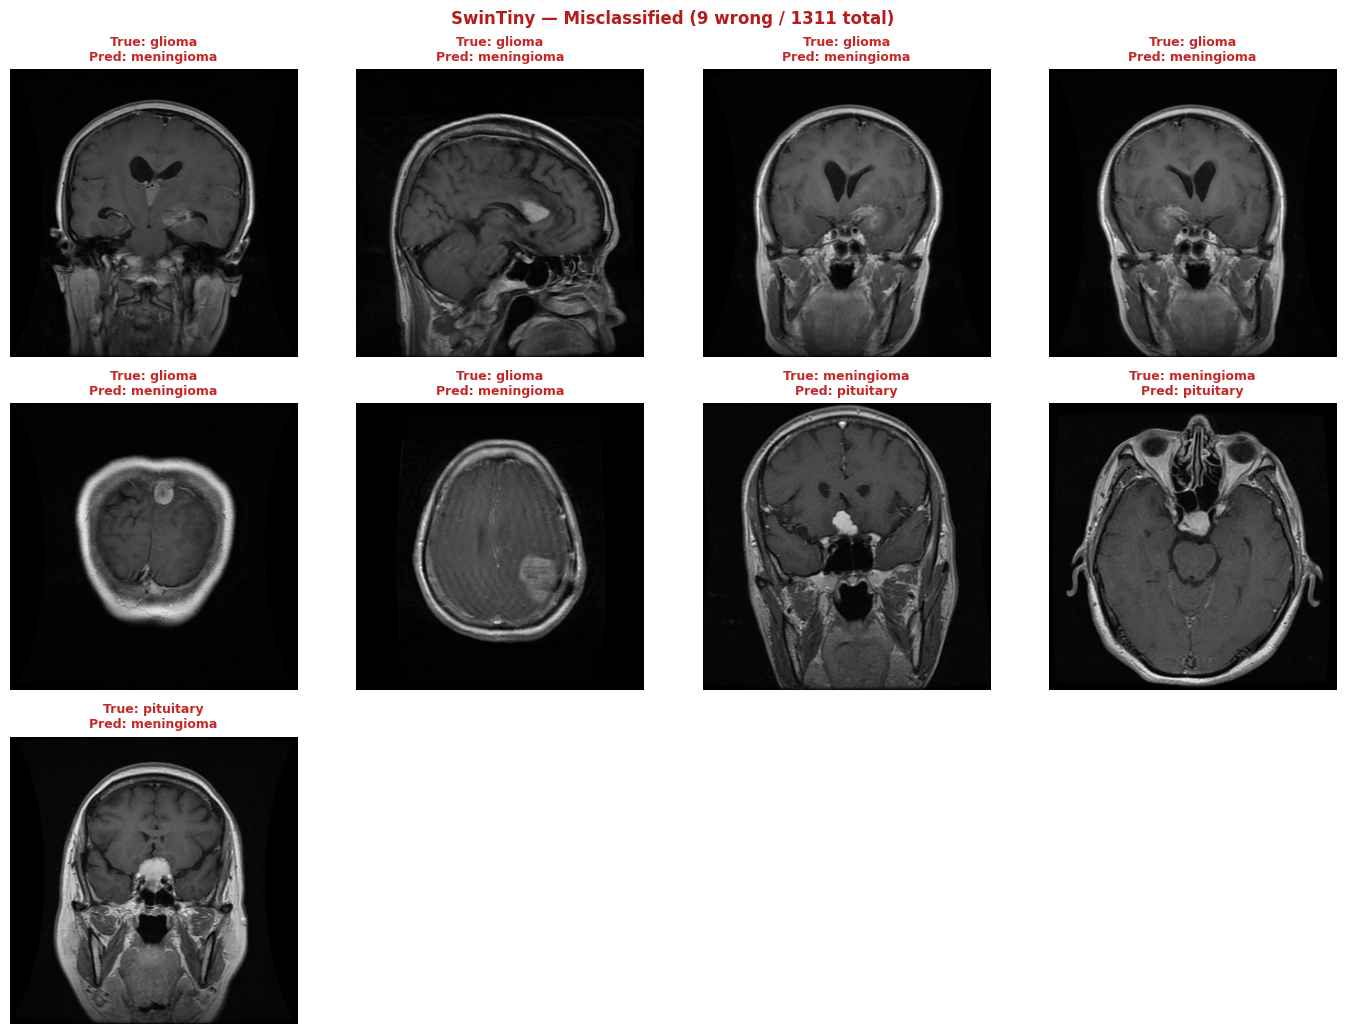

In [19]:
def plot_misclassified(paths, y_true, y_pred, class_names,
                        max_images=16, title="Misclassified Images"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    wrong_idx = np.where(y_true != y_pred)[0]
    total     = len(y_true)

    print("\n" + "="*65)
    print(f"Misclassification Report — {EXPERIMENT}")
    print("="*65)
    print(f"Total wrong: {len(wrong_idx)} / {total} ({100*len(wrong_idx)/total:.2f}%)")
    print(f"\n{'Class':15s} {'Wrong':>6} {'Total':>7} {'Error%':>8}  Confused with")
    print("-"*65)
    for i, cls in enumerate(class_names):
        cls_total = int(np.sum(y_true == i))
        cls_wrong = int(np.sum((y_true == i) & (y_pred != i)))
        err_pct   = 100 * cls_wrong / max(cls_total, 1)
        mask      = (y_true == i) & (y_pred != i)
        if mask.sum() > 0:
            mc = Counter(y_pred[mask].tolist()).most_common(1)[0]
            confused = f"{class_names[mc[0]]} ({mc[1]}x)"
        else:
            confused = "—"
        print(f"{cls:15s} {cls_wrong:>6d} {cls_total:>7d} {err_pct:>7.1f}%  {confused}")

    if len(wrong_idx) == 0:
        print("\n🎉 No misclassifications!")
        return

    sample_idx = wrong_idx[:max_images]
    cols = 4
    rows = (len(sample_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes_flat = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, idx in zip(axes_flat, sample_idx):
        try:
            img = Image.open(paths[idx]).convert("RGB")
        except Exception:
            ax.axis("off"); continue
        ax.imshow(img)
        ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
                     color="#C62828", fontsize=9, fontweight="bold")
        ax.axis("off")
    for ax in axes_flat[len(sample_idx):]:
        ax.axis("off")

    plt.suptitle(f"{title} ({len(wrong_idx)} wrong / {total} total)",
                 fontsize=12, fontweight="bold", color="#B71C1C")
    plt.tight_layout(); plt.show()

if test_paths is not None and test_preds_np is not None:
    plot_misclassified(test_paths, test_true_np, test_preds_np, class_names,
                        max_images=16, title=f"{EXPERIMENT} — Misclassified")


## 20. Grad-CAM++ & Attention Rollout for Swin-Tiny


In [20]:
# ─── Grad-CAM++ ──────────────────────────────────────────────────────────────
class GradCAMPlusPlus:
    """
    Grad-CAM++ targeting Swin-Tiny's last transformer stage.
    Swin activations are (B, H, W, C) — permuted to (B, C, H, W) for CAM math.
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        hook = (target_layer.register_full_backward_hook
                if hasattr(target_layer, "register_full_backward_hook")
                else target_layer.register_backward_hook)
        hook(lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        out[:, class_idx].backward()

        # Swin: (B, H, W, C) → (B, C, H, W)
        acts  = self.activations.permute(0, 3, 1, 2)
        grads = self.gradients.permute(0, 3, 1, 2)

        grads_sq  = grads ** 2
        grads_cub = grads ** 3
        denom   = 2 * grads_sq + (acts * grads_cub).sum(dim=(2, 3), keepdim=True) + 1e-8
        alpha   = grads_sq / denom
        weights = (alpha * torch.relu(grads)).sum(dim=(2, 3))
        cam = torch.relu((weights[0, :, None, None] * acts[0]).sum(0))
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx


# ─── Attention Rollout ────────────────────────────────────────────────────────
class SwinAttentionRollout:
    """
    Attention Rollout for Swin-Tiny.
    Hooks into every WindowAttention block, averages heads, rolls attention
    matrices from shallow → deep to get a single spatial saliency map.
    """
    def __init__(self, model, discard_ratio=0.9):
        self.model         = model
        self.discard_ratio = discard_ratio
        self.attentions    = []
        self._hooks        = []
        self._register()

    def _register(self):
        for module in self.model.modules():
            if module.__class__.__name__ == "WindowAttention":
                self._hooks.append(
                    module.register_forward_hook(self._hook))

    def _hook(self, module, inp, out):
        # Recompute raw attention weights from Q,K inside the hook
        x = inp[0]
        B_, N, _ = x.shape
        qkv = module.qkv(x).reshape(B_, N, 3, module.num_heads, -1).permute(2, 0, 3, 1, 4)
        q, k = qkv[0], qkv[1]
        attn = (q @ k.transpose(-2, -1)) * (q.shape[-1] ** -0.5)
        attn = attn.softmax(dim=-1).detach()
        self.attentions.append(attn.mean(1))   # mean over heads → (B, N, N)

    def __call__(self, x):
        self.attentions = []
        with torch.no_grad():
            _ = self.model(x)

        # Roll out: multiply attention matrices layer by layer
        result = torch.eye(self.attentions[0].shape[-1], device=DEVICE)
        for attn in self.attentions:
            attn = attn.mean(0)                 # mean over batch windows
            if attn.shape[0] != result.shape[0]:
                continue                        # skip mismatched window sizes
            flat  = attn + torch.eye(attn.shape[-1], device=DEVICE)
            flat /= flat.sum(dim=-1, keepdim=True)
            result = flat @ result

        mask = result.mean(0)
        s    = int(mask.shape[0] ** 0.5)
        mask = mask[:s * s].reshape(s, s).cpu().numpy()
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        return mask

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()


print("✅ Grad-CAM++ and Attention Rollout ready for Swin-Tiny")


✅ Grad-CAM++ and Attention Rollout ready for Swin-Tiny


## 21. LIME explainer  *(model-agnostic — works unchanged with Swin-Tiny)*


In [21]:
def explain_with_lime(img_path, model, explainer, num_samples=500):
    model.eval()
    img_np = np.array(Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))

    def batch_predict(images):
        batch = [test_transform(image=im)["image"] for im in images]
        with torch.no_grad():
            out = model(torch.stack(batch).to(DEVICE))
        return softmax_np(out.cpu().numpy())

    explanation = explainer.explain_instance(
        img_np, batch_predict,
        top_labels=1, hide_color=0,
        num_samples=num_samples, random_seed=SEED)
    pred_class = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        pred_class, positive_only=True, num_features=10, hide_rest=False)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img_np); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title(f"LIME — {class_names[pred_class]}"); axes[1].axis("off")
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.vectorize(dict_heatmap.get)(explanation.segments)
    im = axes[2].imshow(heatmap, cmap="RdBu_r",
                         vmin=-abs(heatmap).max(), vmax=abs(heatmap).max())
    plt.colorbar(im, ax=axes[2]); axes[2].set_title("LIME Heatmap"); axes[2].axis("off")
    plt.suptitle(f"LIME — Predicted: {class_names[pred_class]}", fontweight="bold")
    plt.tight_layout(); plt.show()
    return explanation

print(" LIME ready")


 LIME ready


## 22. XAI comparison  (Grad-CAM++ vs Attention Rollout vs LIME)

✅ **FIXED** — `weights_only=False`



XAI Sample: /content/drive/MyDrive/Brain_MRI_Images/Testing/pituitary/Te-pi_0294.jpg

--- Grad-CAM++ ---


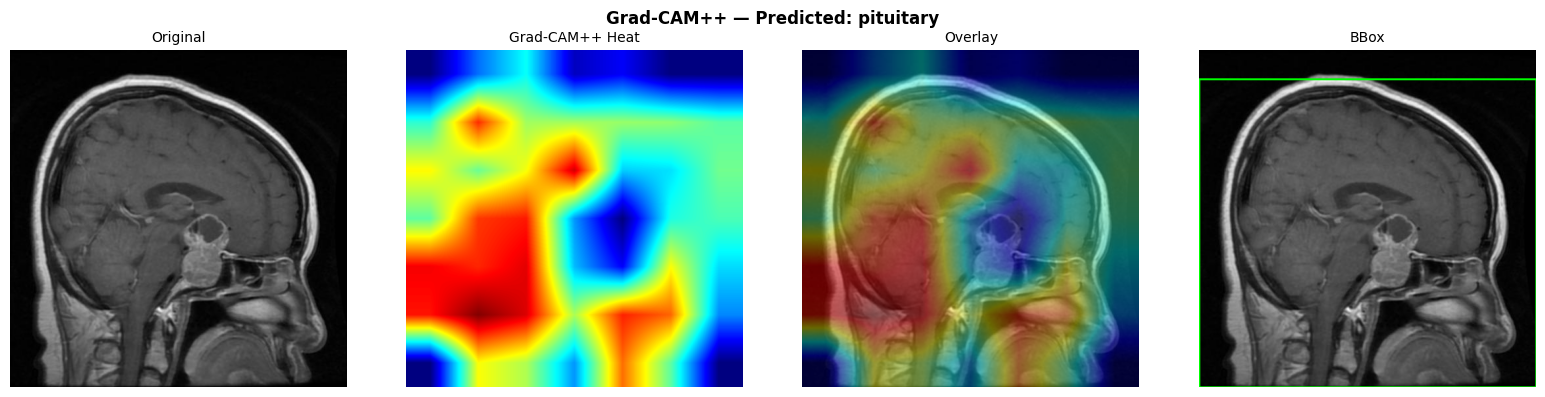


--- Attention Rollout ---


IndexError: list index out of range

In [22]:
# FIXED: weights_only=False added for PyTorch 2.6+ compatibility
def show_gradcampp(img_path, model, gradcam_pp, thresh=0.4):
    """Grad-CAM++ overlay + bounding-box visualisation for Swin-Tiny."""
    img_np = np.array(Image.open(img_path).convert("RGB"))
    tensor = test_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)
    h, w, _ = img_np.shape

    cam, cidx = gradcam_pp(tensor)
    cam_r   = cv2.resize(cam, (w, h))
    heatmap = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.4 * heatmap + 0.6 * img_np)
    mask    = (cam_r >= cam_r.max() * thresh).astype(np.uint8) * 255
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bbox    = img_np.copy()
    if cnts:
        x, y, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        cv2.rectangle(bbox, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, im, t in zip(axes,
                         [img_np, heatmap, overlay, bbox],
                         ["Original", "Grad-CAM++ Heat", "Overlay", "BBox"]):
        ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.suptitle(f"Grad-CAM++ — Predicted: {class_names[cidx]}", fontweight="bold")
    plt.tight_layout(); plt.show()


def show_attention_rollout(img_path, model, rollout):
    """Attention Rollout saliency map for Swin-Tiny."""
    img_np  = np.array(Image.open(img_path).convert("RGB"))
    tensor  = test_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)
    h, w, _ = img_np.shape

    attn_map = rollout(tensor)
    attn_r   = cv2.resize(attn_map, (w, h))
    heatmap  = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * attn_r), cv2.COLORMAP_INFERNO),
        cv2.COLOR_BGR2RGB)
    overlay  = np.uint8(0.45 * heatmap + 0.55 * img_np)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, im, t in zip(axes,
                         [img_np, heatmap, overlay],
                         ["Original", "Attention Rollout", "Overlay"]):
        ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.suptitle("Swin-Tiny — Attention Rollout", fontweight="bold")
    plt.tight_layout(); plt.show()


if best_fold_path:
    # FIX: weights_only=False
    ckpt  = torch.load(best_fold_path, map_location=DEVICE, weights_only=False)
    model = build_swin_tiny(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
    model.load_state_dict(ckpt["state_dict"]); model.eval()

    # Target: last BasicLayer's last SwinTransformerBlock norm1
    target_layer = list(model.features.children())[-1][-1].norm1
    gradcam_pp   = GradCAMPlusPlus(model, target_layer)
    rollout      = SwinAttentionRollout(model, discard_ratio=0.9)
    lime_exp     = lime_image.LimeImageExplainer()

    sample = (random.choice(list(test_paths)) if test_paths is not None
              else random.choice(list(train_paths)))
    print(f"\nXAI Sample: {sample}")

    print("\n--- Grad-CAM++ ---")
    show_gradcampp(sample, model, gradcam_pp)

    print("\n--- Attention Rollout ---")
    show_attention_rollout(sample, model, rollout)
    rollout.remove_hooks()

    print("\n--- LIME Explanation ---")
    explain_with_lime(sample, model, lime_exp, num_samples=LIME_NUM_SAMPLES)


## 23. Per-class XAI grid  (thesis figure)


In [ ]:
if best_fold_path:
    src_p = test_paths  if test_paths  is not None else train_paths
    src_l = test_labels if test_paths  is not None else train_labels

    chosen = {}
    for p, l in zip(src_p, src_l):
        if class_names[l] not in chosen:
            chosen[class_names[l]] = p
        if len(chosen) == num_classes:
            break

    # Rebuild XAI tools if not already in scope
    if "gradcam_pp" not in dir() or "rollout" not in dir():
        ckpt  = torch.load(best_fold_path, map_location=DEVICE, weights_only=False)
        model = build_swin_tiny(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
        model.load_state_dict(ckpt["state_dict"]); model.eval()
        target_layer = list(model.features.children())[-1][-1].norm1
        gradcam_pp   = GradCAMPlusPlus(model, target_layer)
        rollout      = SwinAttentionRollout(model)

    n   = num_classes
    fig = plt.figure(figsize=(20, 5 * n))
    gs  = gridspec.GridSpec(n, 4, figure=fig, hspace=0.35, wspace=0.12)

    for row, cls in enumerate(class_names):
        img_np  = np.array(Image.open(chosen[cls]).convert("RGB"))
        h, w, _ = img_np.shape
        tensor  = test_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)

        # Grad-CAM++
        cam, _  = gradcam_pp(tensor)
        cam_r   = cv2.resize(cam, (w, h))
        heat_gc = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB)
        ov_gc   = np.uint8(0.4 * heat_gc + 0.6 * img_np)

        # Attention Rollout
        attn_map = rollout(tensor)
        attn_r   = cv2.resize(attn_map, (w, h))
        heat_ar  = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255 * attn_r), cv2.COLORMAP_INFERNO),
            cv2.COLOR_BGR2RGB)
        ov_ar    = np.uint8(0.45 * heat_ar + 0.55 * img_np)

        for col, (im, t) in enumerate(zip(
            [img_np, ov_gc, ov_ar, heat_ar],
            [f"{cls}\nOriginal", "Grad-CAM++", "Attn Rollout", "Rollout Heat"]
        )):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")

    plt.suptitle(f"{EXPERIMENT} — Per-Class XAI Grid",
                 fontsize=14, fontweight="bold")
    xai_path = os.path.join(OUTPUT_DIR, f"{EXPERIMENT}_XAI_grid.png")
    plt.savefig(xai_path, dpi=150, bbox_inches="tight")
    plt.show()
    rollout.remove_hooks()
    print(f"✅ XAI grid saved → {xai_path}")


## 24. McNemar test helper (for cross-model comparison)

In [ ]:
def mcnemar_compare_from_files(model_a, model_b, artifacts_dir=None):
    """Compare predictions from two saved models via McNemar test."""
    if artifacts_dir is None:
        artifacts_dir = ARTIFACTS_DIR
    y_true = np.load(os.path.join(artifacts_dir, f"test_true_{model_a}.npy"))
    pa     = np.load(os.path.join(artifacts_dir, f"test_pred_{model_a}.npy"))
    pb     = np.load(os.path.join(artifacts_dir, f"test_pred_{model_b}.npy"))
    ca, cb = (pa == y_true), (pb == y_true)
    n11 = int(np.sum( ca &  cb))
    n10 = int(np.sum( ca & ~cb))
    n01 = int(np.sum(~ca &  cb))
    n00 = int(np.sum(~ca & ~cb))
    result = mcnemar_test([[n11, n10], [n01, n00]], exact=True)
    print(f"\nMcNemar: {model_a} vs {model_b}")
    print(f"  Both correct: {n11} | {model_a} only: {n10} | "
          f"{model_b} only: {n01} | Both wrong: {n00}")
    print(f"  p-value: {result.pvalue:.4f} "
          f"({'SIGNIFICANT' if result.pvalue < 0.05 else 'not significant'})")
    return {
        "model_a": model_a, "model_b": model_b,
        "n11": n11, "n10": n10, "n01": n01, "n00": n00,
        "p_value": float(result.pvalue),
        "significant": bool(result.pvalue < 0.05),
    }

print(f" McNemar ready. After running ResNet50, run:")
print(f"   mcnemar_compare_from_files('{EXPERIMENT}', 'ResNet50')")


## 25. Save results JSON

In [ ]:
def to_serial(obj):
    if isinstance(obj, np.generic):      return obj.item()
    if isinstance(obj, np.ndarray):      return obj.tolist()
    if isinstance(obj, dict):            return {k: to_serial(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):   return [to_serial(x) for x in obj]
    return obj

cv_summary = {}
for key in ["acc", "prec", "rec", "f1", "auc", "kappa", "mcc"]:
    vals = np.array([m[key] for m in all_fold_metrics], dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) > 0:
        boot = [np.mean(np.random.RandomState(i).choice(vals, size=len(vals), replace=True))
                for i in range(BOOTSTRAP_N)]
        cv_summary[key] = {
            "mean":  float(np.mean(vals)),
            "std":   float(np.std(vals)),
            "lower": float(np.percentile(boot, 2.5)),
            "upper": float(np.percentile(boot, 97.5)),
        }

results = {
    "experiment":    EXPERIMENT,
    "dataset":       DATASET_NAME,
    "run_id":        RUN_ID,
    "timestamp":     datetime.now().isoformat(),
    "model_info":    MODEL_INFO,
    "class_names":   class_names,
    "num_classes":   num_classes,
    "train_size":    int(len(train_paths)),
    "test_size":     int(len(test_paths)) if test_paths is not None else 0,
    "fold_metrics":  all_fold_metrics,
    "cv_summary":    cv_summary,
    "best_fold":     best_fold_no,
    "best_fold_path": best_fold_path,
    "training_time": {
        "per_fold_sec": [m["train_time_sec"] for m in all_fold_metrics],
        "avg_fold_min": float(np.mean([m["train_time_sec"] for m in all_fold_metrics]) / 60),
        "total_min":    float(sum(m["train_time_sec"] for m in all_fold_metrics) / 60),
    },
    "test_metrics":  test_result,
    "artifacts_dir": ARTIFACTS_DIR,
    "ckpt_dir":      CKPT_DIR,
    "xai_methods":   ["Grad-CAM", "Grad-CAM++", "LIME"],
}

result_path = os.path.join(OUTPUT_DIR, f"results_{EXPERIMENT}_{DATASET_NAME}_{RUN_ID}.json")
with open(result_path, "w") as f:
    json.dump(to_serial(results), f, indent=2)
print(f"\n Results saved → {result_path}")


## 26. Publication-ready summary table

In [ ]:
print(f"\n{'='*85}")
print(f"{EXPERIMENT} on {DATASET_NAME} — PUBLICATION SUMMARY")
print(f"{'='*85}")
print(f"{'Metric':<10} {'CV Mean':>10} {'CV 95% CI':>24} {'Test':>10} {'Test 95% CI':>24}")
print("-" * 85)
for key in ["acc", "prec", "rec", "f1", "auc", "kappa", "mcc"]:
    cv_v  = cv_summary.get(key, {})
    cv_m  = cv_v.get("mean",  float("nan"))
    cv_l  = cv_v.get("lower", float("nan"))
    cv_u  = cv_v.get("upper", float("nan"))
    tst_v = test_result["ci_95"].get(key, {}) if test_result else {}
    tst_m = test_result.get(key, float("nan")) if test_result else float("nan")
    tst_l = tst_v.get("lower", float("nan"))
    tst_u = tst_v.get("upper", float("nan"))

    cv_ci_str  = f"[{cv_l:.4f}, {cv_u:.4f}]" if not np.isnan(cv_l) else "N/A"
    tst_ci_str = f"[{tst_l:.4f}, {tst_u:.4f}]" if not np.isnan(tst_l) else "N/A"
    marker     = "  ←" if key == BEST_METRIC else ""
    print(f"{key:<10} {cv_m:>10.4f} {cv_ci_str:>24} {tst_m:>10.4f} {tst_ci_str:>24}{marker}")

print("=" * 85)
if test_result is not None:
    print("\nLaTeX table row (copy-paste ready):")
    print(f"VGG16 & {test_result['acc']*100:.2f} & {test_result['prec']*100:.2f} & "
          f"{test_result['rec']*100:.2f} & {test_result['f1']*100:.2f} & "
          f"{test_result['auc']*100:.2f} & {test_result['kappa']:.3f} & "
          f"{test_result['mcc']:.3f} \\\\")

print(f"\n DONE! All outputs in:")
print(f"   Results    : {OUTPUT_DIR}/")
print(f"   Checkpoints: {CKPT_DIR}/")
print(f"   Artifacts  : {ARTIFACTS_DIR}/")
